# Cargar CSV en pandas

Este notebook carga el archivo CSV disponible en la carpeta del proyecto en un DataFrame de pandas.

In [2]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

In [3]:
# Ruta del archivo CSV
csv_path = Path("imputaciones-y-condenas-a-personas.csv")

# Cargar a DataFrame de pandas (con fallback de codificacion)
try:
    df = pd.read_csv(csv_path, sep=",", encoding="utf-8")
except UnicodeDecodeError:
    df = pd.read_csv(csv_path, sep=",", encoding="latin1")

# Normalizar edad a numero entero (mantiene nulos como <NA>)
# Soporta edad en texto con coma decimal: ej. "23,0"
if 'edad' in df.columns:
    edad_limpia = (
        df['edad']
        .astype(str)
        .str.strip()
        .replace({'': pd.NA, 'nan': pd.NA, 'None': pd.NA})
        .str.replace(',', '.', regex=False)
    )
    df['edad'] = pd.to_numeric(edad_limpia, errors='coerce').round().astype('Int64')

print(f"Archivo cargado: {csv_path}")
print(f"Filas: {df.shape[0]} | Columnas: {df.shape[1]}")

Archivo cargado: imputaciones-y-condenas-a-personas.csv
Filas: 122255 | Columnas: 19


In [90]:
# Vista previa de los datos
df.head(20)

,id_ncci,id_nunc,id_documento,Titulo_denuncia,depto_hechos,fecha_hecho,mes_primera_audi,fecha_primera_audi,fecha_resolución,edad,edad_tramos,sexo_persona,delito_imputado,delitos_agrupados,situación_procesal,delito_1,delito_2,delito_3,delito_4
0,65259fe81b747c5bf850a4d0285f109f,5d80fd27a6f284d2f0704e26dd65494e,a473c2e40ac3f3b2803fd2d7ee276ce6,HURTO,MONTEVIDEO,2017-11-01,2019-08,2019-08-14,2019-08-14,36,36-45,M,HURTO,HURTO,SUSPENSION CONDICIONAL,HURTO,NaN,NaN,NaN
1,a57b0000d41f403eae7fb5a6c208f472,cbb57405725f99f5bd24e8a0c4fd20b1,852bf4b2517ee362ecefb419b5e1e7ff,LESIONES PERSONALES,MONTEVIDEO,2017-11-01,2019-03,2019-03-19,2019-03-19,38,36-45,M,HOMICIDIO,HOMICIDIO,PROCESO ABREVIADO/ SIMPLIFICADO,HOMICIDIO,NaN,NaN,NaN
2,c6055dbbc381abb7b79781b4fcb67b9a,917a60406934e5276b51f504ebe8d873,28c4a81db66f7b2e3995e5a7f5a673ae,HURTO,MONTEVIDEO,2017-10-29,2020-06,2020-06-22,2020-06-22,18,18-25,M,RECEPTACIÓN,OTROS DELITOS,PROCESO ABREVIADO/ SIMPLIFICADO,RECEPTACIÓN,NaN,NaN,NaN
3,909c4f4fea09b74cf788cd7e94ee7d1d,8332a330ab57c92aaaff58a7f3dd3f24,b31313f0b13d7011c730ef1b226f6429,ATENTADO VIOLENTO AL PUDOR,RIVERA,2017-11-01,2023-05,2023-05-03,2023-05-03,41,36-45,M,ATENTADO VIOLENTO AL PUDOR,Delitos sexuales,PROCESO ABREVIADO/ SIMPLIFICADO,ATENTADO VIOLENTO AL PUDOR,NaN,NaN,NaN
4,2cd1030ef397b7cba4a594fb50f6eeae,4a4d10eded8945c32f403dfa594a2238,e3d6f98d8ccaf47c4b7d9f0940a25ea1,CHEQUES,MONTEVIDEO,2017-10-31,2020-09,2020-09-23,2020-09-23,41,36-45,F,CHEQUES,CHEQUES,PROCESO ABREVIADO/ SIMPLIFICADO,CHEQUES,NaN,NaN,NaN
5,23ace8f7f1d9feb32c4d3194c6913c2c,ca31868e42cd4244207bb13bbad21f96,c00deeeeda4b1a3ef67bc8fa8b259a6b,HURTO,MONTEVIDEO,2017-11-03,2019-05,2019-05-21,2019-05-21,37,36-45,F,HURTO,HURTO,SUSPENSION CONDICIONAL,HURTO,NaN,NaN,NaN
6,4275d4a0d88124561c125738a1a6a7e5,854cc70800902e4b97760075d9a27c87,260c1514b7fb531f32a45481df9fb795,ATENTADO,MONTEVIDEO,2017-11-03,2019-03,2019-03-13,2019-03-13,31,26-35,F,ATENTADO,OTROS DELITOS,PROCESO ABREVIADO/ SIMPLIFICADO,ATENTADO,NaN,NaN,NaN
7,e6d0d6a59f6ea01975c40cc77ce56e87,4f49cf4e35fa311b7a961ef8941f0154,54f07267c7131d656d8af97b49e2db39,VIOLENCIA DOMÉSTICA,CANELONES,2017-11-04,2019-08,2019-08-09,2021-05-11,39,36-45,M,VIOLENCIA DOMÉSTICA,VIOLENCIA DOMÉSTICA,PROCESO ABREVIADO/ SIMPLIFICADO,VIOLENCIA DOMÉSTICA,NaN,NaN,NaN
8,152b247f3a3f38966d51c86bfba157d2,86c284c0ecae2d8e246d159bfc9e0973,2c1d6fad7883dd67ab0e4a4ea7d754a7,APROPIACIÓN INDEBIDA,CANELONES,2017-11-03,2019-06,2019-06-07,2019-06-07,38,36-45,F,APROPIACIÓN DE COSAS PERDIDAS O HABIDAS POR ER...,OTROS DELITOS,EN ACUERDO REPARATORIO,APROPIACIÓN DE COSAS PERDIDAS O HABIDAS POR ER...,NaN,NaN,NaN
9,2589c157b600d1bb31894e3f350ad2b4,a99be4518ebe06478a888b06c7022e4c,80ad30bec53447614068d1f4cf058faf,ATENTADO VIOLENTO AL PUDOR,COLONIA,2017-11-04,2022-02,2022-02-14,2022-06-10,40,36-45,M,ATENTADO VIOLENTO AL PUDOR,Delitos sexuales,PROCESO ABREVIADO/ SIMPLIFICADO,ATENTADO VIOLENTO AL PUDOR,NaN,NaN,NaN


In [89]:
# Reemplazar NaN por cadena vacia (mantiene intacto df para analisis)
# Se convierte a object para permitir '' tambien en columnas numericas como edad.
df_sin_nan = df.astype('object').fillna("")

df_sin_nan.head(10)

,id_ncci,id_nunc,id_documento,Titulo_denuncia,depto_hechos,fecha_hecho,mes_primera_audi,fecha_primera_audi,fecha_resolución,edad,edad_tramos,sexo_persona,delito_imputado,delitos_agrupados,situación_procesal,delito_1,delito_2,delito_3,delito_4
0,65259fe81b747c5bf850a4d0285f109f,5d80fd27a6f284d2f0704e26dd65494e,a473c2e40ac3f3b2803fd2d7ee276ce6,HURTO,MONTEVIDEO,2017-11-01 00:00:00,2019-08,2019-08-14,2019-08-14,36,36-45,M,HURTO,HURTO,SUSPENSION CONDICIONAL,HURTO,,,
1,a57b0000d41f403eae7fb5a6c208f472,cbb57405725f99f5bd24e8a0c4fd20b1,852bf4b2517ee362ecefb419b5e1e7ff,LESIONES PERSONALES,MONTEVIDEO,2017-11-01 00:00:00,2019-03,2019-03-19,2019-03-19,38,36-45,M,HOMICIDIO,HOMICIDIO,PROCESO ABREVIADO/ SIMPLIFICADO,HOMICIDIO,,,
2,c6055dbbc381abb7b79781b4fcb67b9a,917a60406934e5276b51f504ebe8d873,28c4a81db66f7b2e3995e5a7f5a673ae,HURTO,MONTEVIDEO,2017-10-29 00:00:00,2020-06,2020-06-22,2020-06-22,18,18-25,M,RECEPTACIÓN,OTROS DELITOS,PROCESO ABREVIADO/ SIMPLIFICADO,RECEPTACIÓN,,,
3,909c4f4fea09b74cf788cd7e94ee7d1d,8332a330ab57c92aaaff58a7f3dd3f24,b31313f0b13d7011c730ef1b226f6429,ATENTADO VIOLENTO AL PUDOR,RIVERA,2017-11-01 00:00:00,2023-05,2023-05-03,2023-05-03,41,36-45,M,ATENTADO VIOLENTO AL PUDOR,Delitos sexuales,PROCESO ABREVIADO/ SIMPLIFICADO,ATENTADO VIOLENTO AL PUDOR,,,
4,2cd1030ef397b7cba4a594fb50f6eeae,4a4d10eded8945c32f403dfa594a2238,e3d6f98d8ccaf47c4b7d9f0940a25ea1,CHEQUES,MONTEVIDEO,2017-10-31 00:00:00,2020-09,2020-09-23,2020-09-23,41,36-45,F,CHEQUES,CHEQUES,PROCESO ABREVIADO/ SIMPLIFICADO,CHEQUES,,,
5,23ace8f7f1d9feb32c4d3194c6913c2c,ca31868e42cd4244207bb13bbad21f96,c00deeeeda4b1a3ef67bc8fa8b259a6b,HURTO,MONTEVIDEO,2017-11-03 00:00:00,2019-05,2019-05-21,2019-05-21,37,36-45,F,HURTO,HURTO,SUSPENSION CONDICIONAL,HURTO,,,
6,4275d4a0d88124561c125738a1a6a7e5,854cc70800902e4b97760075d9a27c87,260c1514b7fb531f32a45481df9fb795,ATENTADO,MONTEVIDEO,2017-11-03 00:00:00,2019-03,2019-03-13,2019-03-13,31,26-35,F,ATENTADO,OTROS DELITOS,PROCESO ABREVIADO/ SIMPLIFICADO,ATENTADO,,,
7,e6d0d6a59f6ea01975c40cc77ce56e87,4f49cf4e35fa311b7a961ef8941f0154,54f07267c7131d656d8af97b49e2db39,VIOLENCIA DOMÉSTICA,CANELONES,2017-11-04 00:00:00,2019-08,2019-08-09,2021-05-11,39,36-45,M,VIOLENCIA DOMÉSTICA,VIOLENCIA DOMÉSTICA,PROCESO ABREVIADO/ SIMPLIFICADO,VIOLENCIA DOMÉSTICA,,,
8,152b247f3a3f38966d51c86bfba157d2,86c284c0ecae2d8e246d159bfc9e0973,2c1d6fad7883dd67ab0e4a4ea7d754a7,APROPIACIÓN INDEBIDA,CANELONES,2017-11-03 00:00:00,2019-06,2019-06-07,2019-06-07,38,36-45,F,APROPIACIÓN DE COSAS PERDIDAS O HABIDAS POR ER...,OTROS DELITOS,EN ACUERDO REPARATORIO,APROPIACIÓN DE COSAS PERDIDAS O HABIDAS POR ER...,,,
9,2589c157b600d1bb31894e3f350ad2b4,a99be4518ebe06478a888b06c7022e4c,80ad30bec53447614068d1f4cf058faf,ATENTADO VIOLENTO AL PUDOR,COLONIA,2017-11-04 00:00:00,2022-02,2022-02-14,2022-06-10,40,36-45,M,ATENTADO VIOLENTO AL PUDOR,Delitos sexuales,PROCESO ABREVIADO/ SIMPLIFICADO,ATENTADO VIOLENTO AL PUDOR,,,


# ordenamiento de delitos por tipo

In [76]:
# Asegurar formato de fecha
df['fecha_hecho'] = pd.to_datetime(df['fecha_hecho'], errors='coerce')

# Filtrar filas con fecha, departamento y delito válidos
df_delitos_departamento = df.dropna(subset=['fecha_hecho', 'depto_hechos', 'delitos_agrupados']).copy()

# Dataset ordenado de forma descendente por numero de delitos
tipo_delitos_ordenados = (
    df_delitos_departamento.groupby('delitos_agrupados', as_index=False)
    .size()
    .rename(columns={'size': 'numero_delitos'})
    .sort_values('numero_delitos', ascending=False)
    .reset_index(drop=True)
)

# Agrupar por mes para ver evolución temporal
evolucion = (
    df_delitos_departamento
    .assign(periodo=df_delitos_departamento['fecha_hecho'].dt.to_period('M').dt.to_timestamp())
    .groupby(['periodo', 'depto_hechos', 'delitos_agrupados'], as_index=False)
    .size()
    .rename(columns={'size': 'cantidad'})
)

print(f'Registros para análisis: {len(df_delitos_departamento)}')
tipo_delitos_ordenados.head(20)

Registros para análisis: 122226


,delitos_agrupados,numero_delitos
0,HURTO,40493
1,OTROS DELITOS,26426
2,ESTUPEFACIENTES,9520
3,RAPIÑA,8998
4,VIOLENCIA DOMÉSTICA,7039
5,DESACATO,6102
6,Armas de fuego y explosivos,4801
7,HOMICIDIO,3289
8,Delitos sexuales,3177
9,LESIONES PERSONALES,3117


In [77]:
## Ordenamiento de delitos por departamento


In [78]:

# Dataset ordenado de forma descendente por numero de delitos por departamento
delitos_por_departamento = (
    df_delitos_departamento.groupby('depto_hechos', as_index=False)
    .size()
    .rename(columns={'size': 'numero_delitos'})
    .sort_values('numero_delitos', ascending=False)
    .reset_index(drop=True)
)

# Agrupar por mes para ver evolución temporal
evolucion = (
    df_delitos_departamento
    .assign(periodo=df_delitos_departamento['fecha_hecho'].dt.to_period('M').dt.to_timestamp())
    .groupby(['periodo', 'depto_hechos', 'delitos_agrupados'], as_index=False)
    .size()
    .rename(columns={'size': 'cantidad'})
)

print(f'Registros para análisis: {len(df_delitos_departamento)}')
delitos_por_departamento

Registros para análisis: 122226


,depto_hechos,numero_delitos
0,MONTEVIDEO,43775
1,CANELONES,18305
2,MALDONADO,7478
3,SALTO,5832
4,CERRO LARGO,4933
5,RIVERA,4924
6,PAYSANDU,4592
7,SORIANO,4159
8,SAN JOSE,4149
9,COLONIA,3454


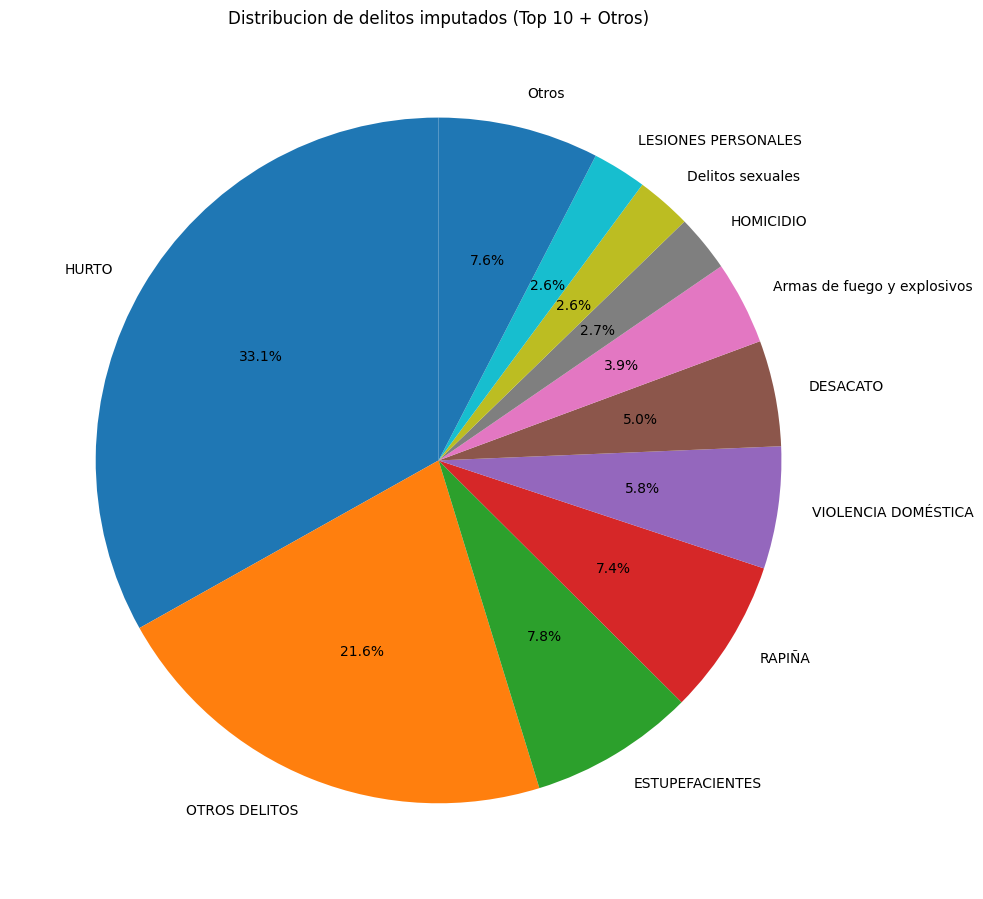

In [79]:
# Pie chart por delito imputado (Top 10 + Otros)
top10 = tipo_delitos_ordenados.head(10).copy()
otros = tipo_delitos_ordenados['numero_delitos'].iloc[10:].sum()

pie_data = top10[['delitos_agrupados', 'numero_delitos']].copy()
pie_data.loc[len(pie_data)] = ['Otros', otros]

plt.figure(figsize=(10, 10))
plt.pie(
    pie_data['numero_delitos'],
    labels=pie_data['delitos_agrupados'],
    autopct='%1.1f%%',
    startangle=90
)
plt.title('Distribucion de delitos imputados (Top 10 + Otros)')
plt.tight_layout()
plt.show()

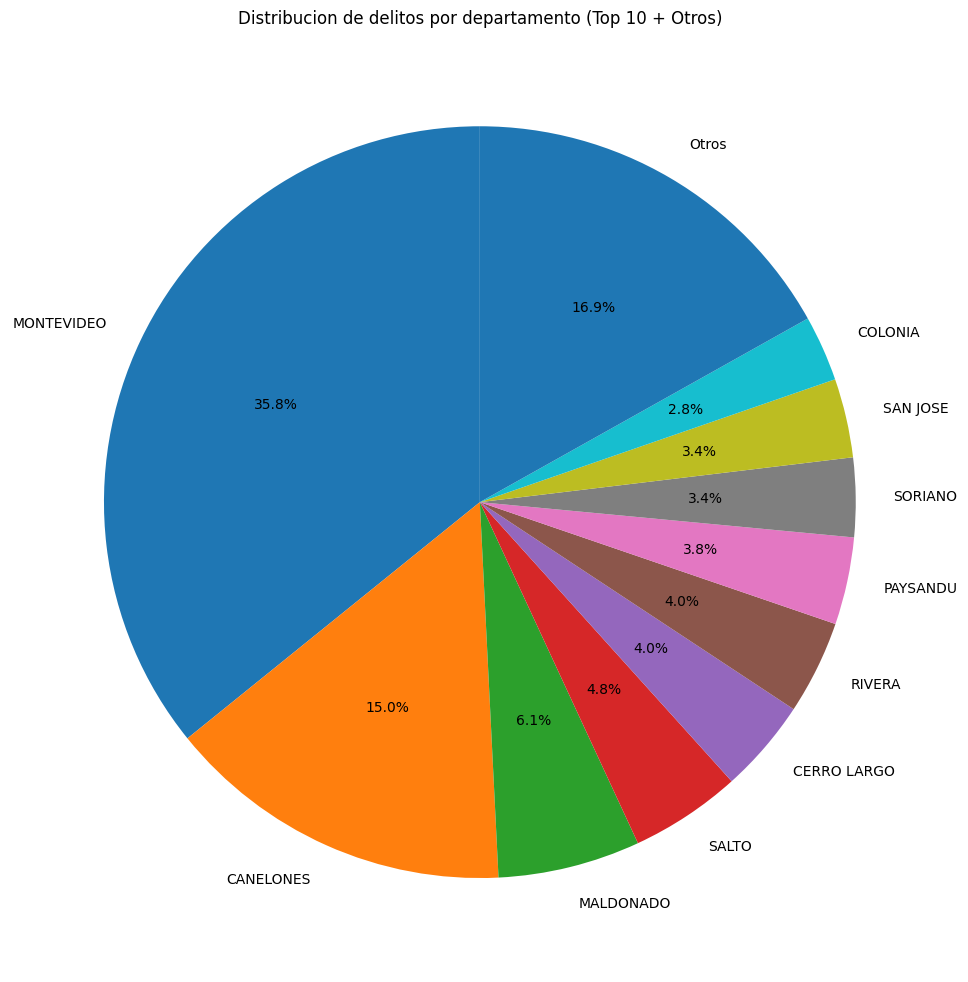

In [80]:
# Pie chart por departamento (Top 10 + Otros)
top10 = delitos_por_departamento.head(10).copy()
otros = delitos_por_departamento['numero_delitos'].iloc[10:].sum()

pie_data = top10[['depto_hechos', 'numero_delitos']].copy()
pie_data.loc[len(pie_data)] = ['Otros', otros]

plt.figure(figsize=(10, 10))
plt.pie(
    pie_data['numero_delitos'],
    labels=pie_data['depto_hechos'],
    autopct='%1.1f%%',
    startangle=90
)
plt.title('Distribucion de delitos por departamento (Top 10 + Otros)')
plt.tight_layout()
plt.show()

## Evolución temporal de delito_imputado por depto_hechos
Se convierte `fecha_hecho` a fecha, se agrupa por mes/departamento/delito y se grafica la cantidad de casos en el tiempo.

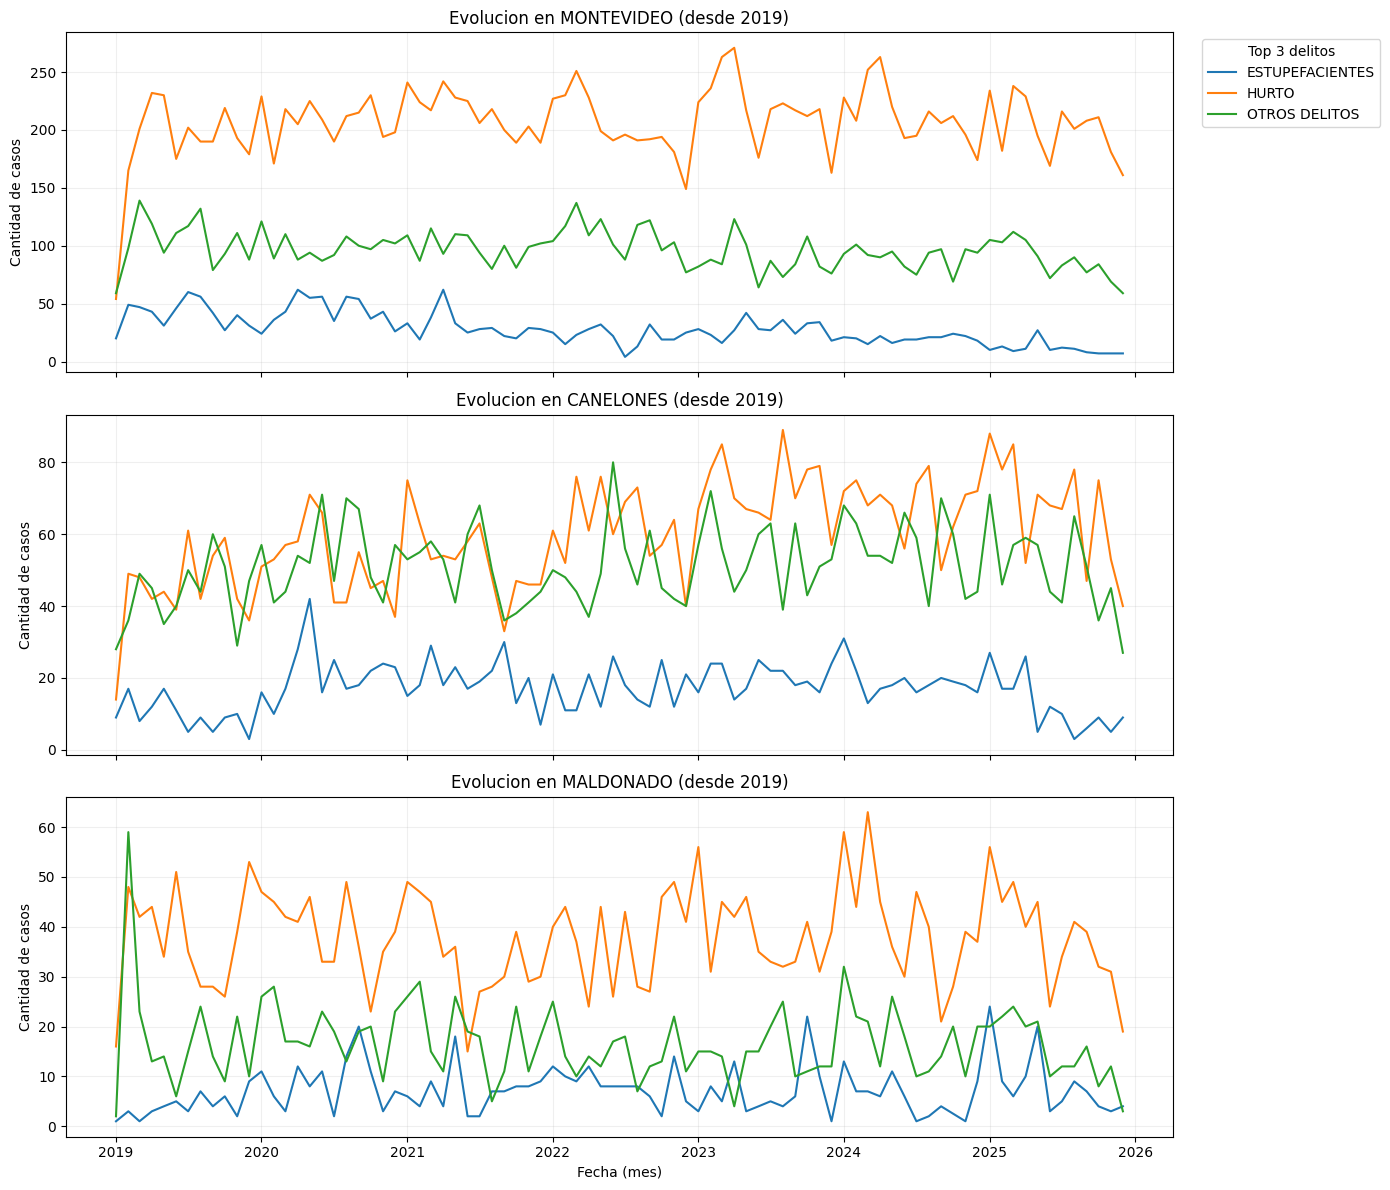

Top 3 delitos (desde 2019): ['HURTO', 'OTROS DELITOS', 'ESTUPEFACIENTES']
Top 3 departamentos (desde 2019): ['MONTEVIDEO', 'CANELONES', 'MALDONADO']


In [81]:
# Top 3 delitos en Top 3 departamentos (filtrado desde 2019)
fecha_inicio = pd.Timestamp('2019-01-01')
base_2019 = df_delitos_departamento[df_delitos_departamento['fecha_hecho'] >= fecha_inicio].copy()

top3_delitos_2019 = (
    base_2019.groupby('delitos_agrupados', as_index=False)
    .size()
    .sort_values('size', ascending=False)
    .head(3)['delitos_agrupados']
    .tolist()
)

top3_deptos_2019 = (
    base_2019.groupby('depto_hechos', as_index=False)
    .size()
    .sort_values('size', ascending=False)
    .head(3)['depto_hechos']
    .tolist()
)

evolucion_2019 = (
    base_2019
    .assign(periodo=base_2019['fecha_hecho'].dt.to_period('M').dt.to_timestamp())
    .groupby(['periodo', 'depto_hechos', 'delitos_agrupados'], as_index=False)
    .size()
    .rename(columns={'size': 'cantidad'})
)

evolucion_top_2019 = evolucion_2019[
    evolucion_2019['delitos_agrupados'].isin(top3_delitos_2019) &
    evolucion_2019['depto_hechos'].isin(top3_deptos_2019)
]

fig, axes = plt.subplots(len(top3_deptos_2019), 1, figsize=(14, 12), sharex=True)
if len(top3_deptos_2019) == 1:
    axes = [axes]

for ax, depto in zip(axes, top3_deptos_2019):
    data_depto = evolucion_top_2019[evolucion_top_2019['depto_hechos'] == depto]
    for delito, grp in data_depto.groupby('delitos_agrupados'):
        grp = grp.sort_values('periodo')
        ax.plot(grp['periodo'], grp['cantidad'], label=delito)
    ax.set_title(f'Evolucion en {depto} (desde 2019)')
    ax.set_ylabel('Cantidad de casos')
    ax.grid(alpha=0.2)

axes[-1].set_xlabel('Fecha (mes)')
axes[0].legend(title='Top 3 delitos', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

print('Top 3 delitos (desde 2019):', top3_delitos_2019)
print('Top 3 departamentos (desde 2019):', top3_deptos_2019)

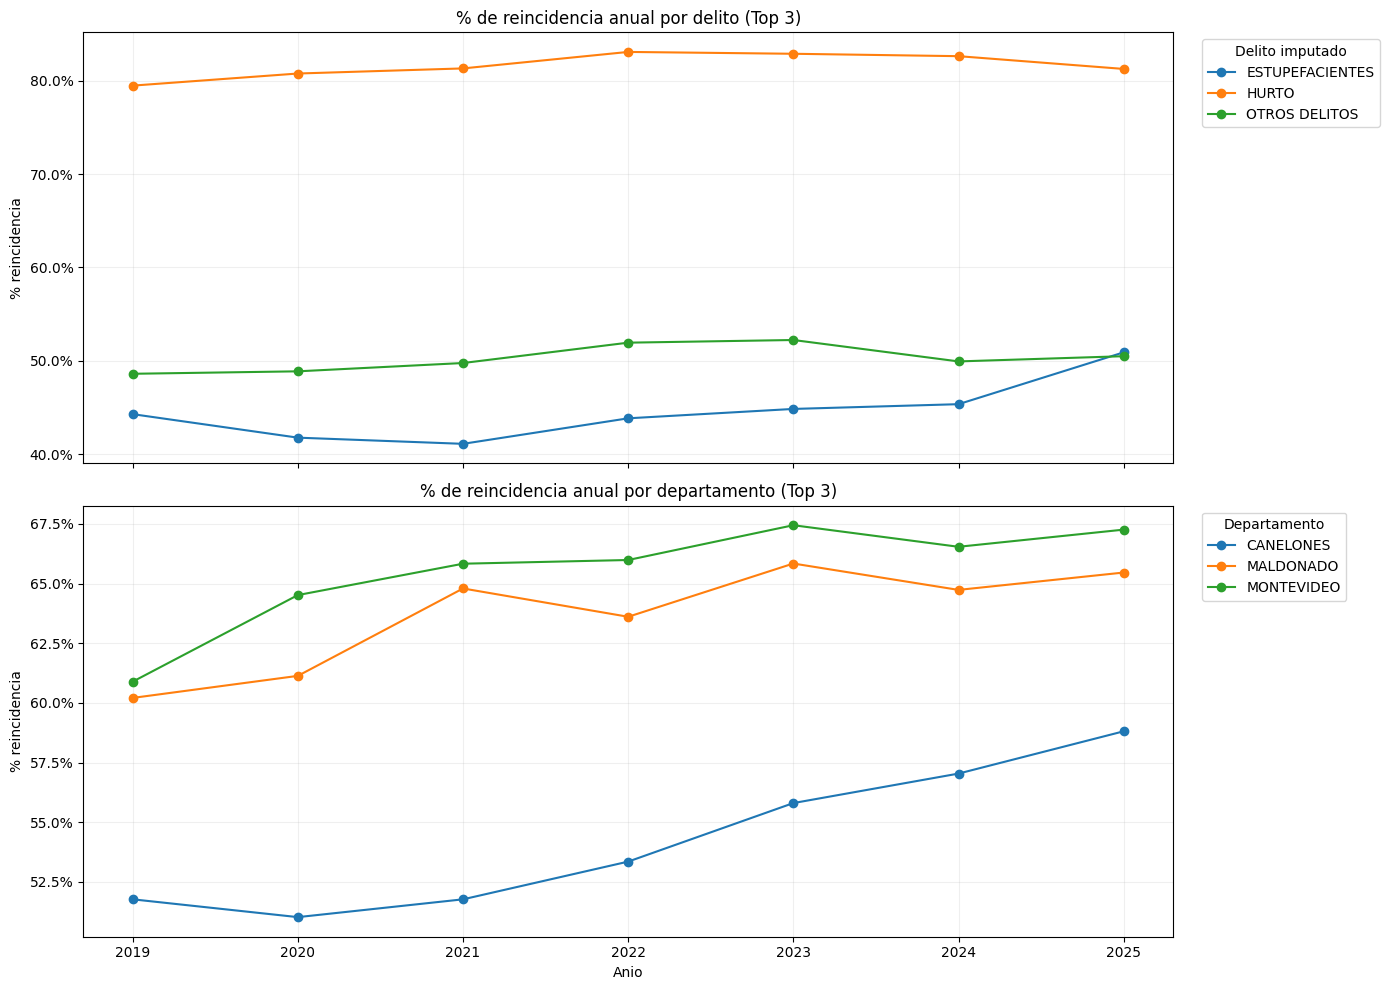

Top 3 delitos: ['HURTO', 'OTROS DELITOS', 'ESTUPEFACIENTES']
Top 3 departamentos: ['MONTEVIDEO', 'CANELONES', 'MALDONADO']
Cantidad de id_documento reincidentes globales: 23845

% reincidencia por delito (Top 3):


,delitos_agrupados,casos_totales,casos_reincidentes,pct_reincidencia
1,HURTO,39833,32548,81.711144
2,OTROS DELITOS,25280,12703,50.249209
0,ESTUPEFACIENTES,9345,4126,44.151953



% reincidencia por departamento (Top 3):


,depto_hechos,casos_totales,casos_reincidentes,pct_reincidencia
2,MONTEVIDEO,42265,27657,65.437123
1,MALDONADO,7299,4641,63.584053
0,CANELONES,17789,9668,54.348193


In [82]:
# % de reincidencia (top 5 delitos y top 5 departamentos) + evolucion anual
import matplotlib.ticker as mtick

# 1) IDs reincidentes en el dataset original (aparecen mas de 1 vez)
ids_reincidentes_global = (
    df.dropna(subset=['id_documento'])
    .groupby('id_documento')
    .size()
)
ids_reincidentes_global = ids_reincidentes_global[ids_reincidentes_global > 1].index

# 2) Base de analisis desde 2019 (para evitar sesgo por reincidencia previa a 2019)
fecha_inicio_rec = pd.Timestamp('2019-01-01')
base_analisis = df.dropna(subset=['id_documento', 'fecha_hecho', 'depto_hechos', 'delitos_agrupados']).copy()
base_analisis = base_analisis[base_analisis['fecha_hecho'] >= fecha_inicio_rec].copy()
base_analisis['es_reincidente_global'] = base_analisis['id_documento'].isin(ids_reincidentes_global)
base_analisis['anio'] = base_analisis['fecha_hecho'].dt.year

# 3) Top 3 delitos y top 3 departamentos por cantidad de casos
top3_delitos_rec = (
    base_analisis.groupby('delitos_agrupados', as_index=False)
    .size()
    .sort_values('size', ascending=False)
    .head(3)['delitos_agrupados']
    .tolist()
)

top3_deptos_rec = (
    base_analisis.groupby('depto_hechos', as_index=False)
    .size()
    .sort_values('size', ascending=False)
    .head(3)['depto_hechos']
    .tolist()
)

# 4) % de reincidencia por delito (top 3)
tabla_pct_delito = (
    base_analisis[base_analisis['delitos_agrupados'].isin(top3_delitos_rec)]
    .groupby('delitos_agrupados', as_index=False)
    .agg(
        casos_totales=('id_documento', 'size'),
        casos_reincidentes=('es_reincidente_global', 'sum')
    )
)
tabla_pct_delito['pct_reincidencia'] = (
    tabla_pct_delito['casos_reincidentes'] / tabla_pct_delito['casos_totales'] * 100
)
tabla_pct_delito = tabla_pct_delito.sort_values('pct_reincidencia', ascending=False)

# 5) % de reincidencia por departamento (top 3)
tabla_pct_depto = (
    base_analisis[base_analisis['depto_hechos'].isin(top3_deptos_rec)]
    .groupby('depto_hechos', as_index=False)
    .agg(
        casos_totales=('id_documento', 'size'),
        casos_reincidentes=('es_reincidente_global', 'sum')
    )
)
tabla_pct_depto['pct_reincidencia'] = (
    tabla_pct_depto['casos_reincidentes'] / tabla_pct_depto['casos_totales'] * 100
)
tabla_pct_depto = tabla_pct_depto.sort_values('pct_reincidencia', ascending=False)

# 6) Evolucion anual del % de reincidencia por delito (top 3)
evolucion_anual_delito = (
    base_analisis[base_analisis['delitos_agrupados'].isin(top3_delitos_rec)]
    .groupby(['anio', 'delitos_agrupados'], as_index=False)
    .agg(
        casos_totales=('id_documento', 'size'),
        casos_reincidentes=('es_reincidente_global', 'sum')
    )
)
evolucion_anual_delito['pct_reincidencia'] = (
    evolucion_anual_delito['casos_reincidentes'] / evolucion_anual_delito['casos_totales'] * 100
)

# 7) Evolucion anual del % de reincidencia por departamento (top 3)
evolucion_anual_depto = (
    base_analisis[base_analisis['depto_hechos'].isin(top3_deptos_rec)]
    .groupby(['anio', 'depto_hechos'], as_index=False)
    .agg(
        casos_totales=('id_documento', 'size'),
        casos_reincidentes=('es_reincidente_global', 'sum')
    )
)
evolucion_anual_depto['pct_reincidencia'] = (
    evolucion_anual_depto['casos_reincidentes'] / evolucion_anual_depto['casos_totales'] * 100
)

# 8) Graficos de evolucion anual
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

for delito, grp in evolucion_anual_delito.groupby('delitos_agrupados'):
    grp = grp.sort_values('anio')
    axes[0].plot(grp['anio'], grp['pct_reincidencia'], marker='o', label=delito)
axes[0].set_title('% de reincidencia anual por delito (Top 3)')
axes[0].set_ylabel('% reincidencia')
axes[0].grid(alpha=0.2)
axes[0].legend(title='Delito imputado', bbox_to_anchor=(1.02, 1), loc='upper left')
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter())

for depto, grp in evolucion_anual_depto.groupby('depto_hechos'):
    grp = grp.sort_values('anio')
    axes[1].plot(grp['anio'], grp['pct_reincidencia'], marker='o', label=depto)
axes[1].set_title('% de reincidencia anual por departamento (Top 3)')
axes[1].set_xlabel('Anio')
axes[1].set_ylabel('% reincidencia')
axes[1].grid(alpha=0.2)
axes[1].legend(title='Departamento', bbox_to_anchor=(1.02, 1), loc='upper left')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())

plt.tight_layout()
plt.show()

print('Top 3 delitos:', top3_delitos_rec)
print('Top 3 departamentos:', top3_deptos_rec)
print('Cantidad de id_documento reincidentes globales:', len(ids_reincidentes_global))

print('\n% reincidencia por delito (Top 3):')
display(tabla_pct_delito)

print('\n% reincidencia por departamento (Top 3):')
display(tabla_pct_depto)

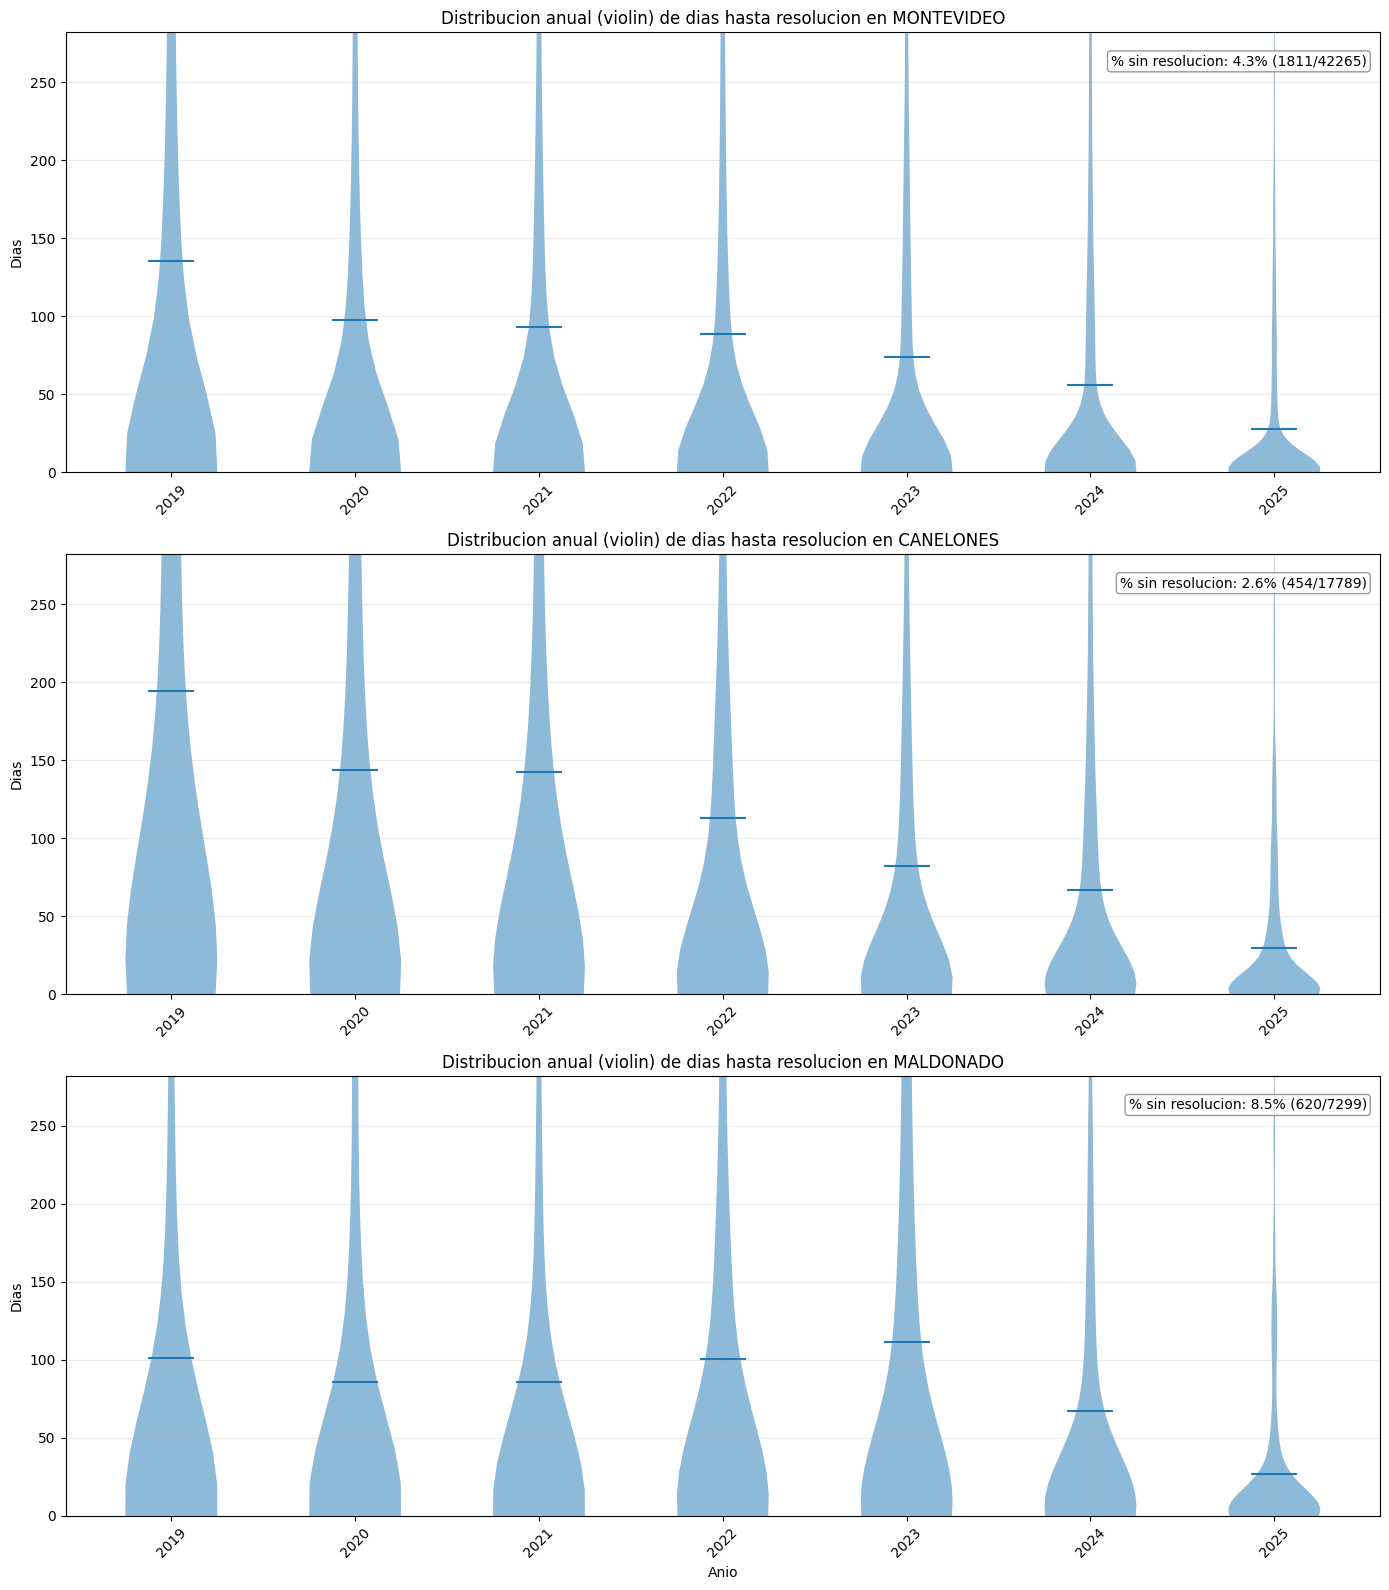

Limite superior eje Y (percentil 90): 282.0 dias
Top 3 departamentos (casos totales): ['MONTEVIDEO', 'CANELONES', 'MALDONADO']

% de casos sin resolucion por departamento:


,depto_hechos,casos_evaluados,casos_sin_resolucion,pct_sin_resolucion
2,MONTEVIDEO,42265,1811,4.284869
1,MALDONADO,7299,620,8.494314
0,CANELONES,17789,454,2.552139


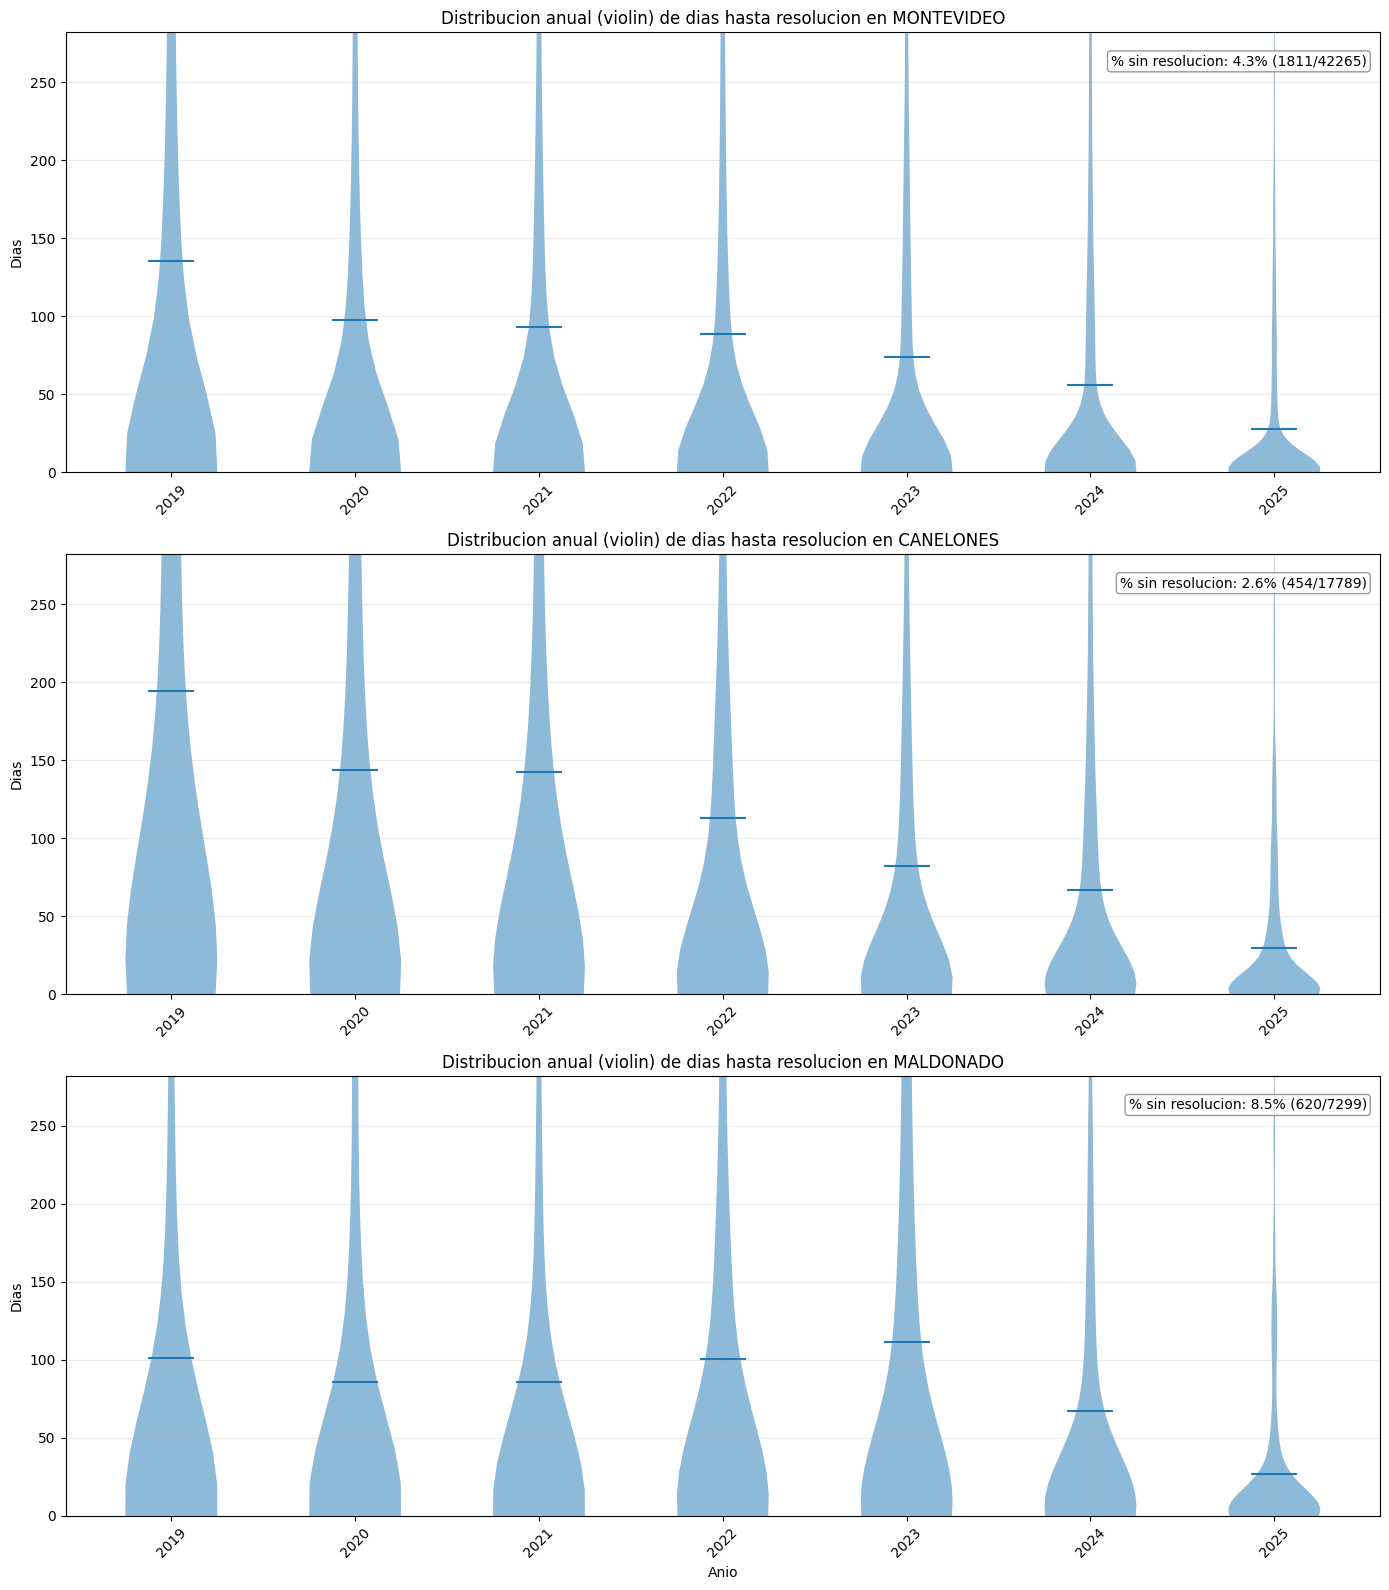

Limite superior eje Y (percentil 90): 282.0 dias
Top 3 departamentos (casos totales): ['MONTEVIDEO', 'CANELONES', 'MALDONADO']

% de casos sin resolucion por departamento:


,depto_hechos,casos_evaluados,casos_sin_resolucion,pct_sin_resolucion
2,MONTEVIDEO,42265,1811,4.284869
1,MALDONADO,7299,620,8.494314
0,CANELONES,17789,454,2.552139



Resumen anual (incluye casos evaluados y resueltos):


,anio,depto_hechos,promedio_dias,desvio_std_dias,n_casos_resueltos,casos_evaluados
2,2019,MONTEVIDEO,135.416308,287.531118,6034,6285
5,2020,MONTEVIDEO,97.284091,227.902803,6160,6406
8,2021,MONTEVIDEO,92.838759,216.620014,5898,6026
11,2022,MONTEVIDEO,88.597416,194.120017,5805,5980
14,2023,MONTEVIDEO,73.787446,150.415514,6022,6220
17,2024,MONTEVIDEO,56.022268,111.071861,5793,6058
20,2025,MONTEVIDEO,27.653026,59.050602,4692,5290
13,2023,MALDONADO,111.576327,187.911164,904,1007
1,2019,MALDONADO,101.516537,241.330362,1028,1048
10,2022,MALDONADO,100.812081,200.674195,894,981


In [83]:
# Tiempo entre fecha_hecho y fecha_resolucion por departamento (Top 3), promedio y desviacion estandar anual
import numpy as np

# Detectar columna de fecha de resolucion (puede variar por codificacion)
col_res_candidates = [c for c in df.columns if c.lower().startswith('fecha_resoluci')]
if not col_res_candidates:
    raise ValueError('No se encontro la columna de fecha_resolucion en el dataset.')
col_fecha_resolucion = col_res_candidates[0]

base_tiempo = df.copy()
base_tiempo['fecha_hecho'] = pd.to_datetime(base_tiempo['fecha_hecho'], errors='coerce')
base_tiempo[col_fecha_resolucion] = pd.to_datetime(base_tiempo[col_fecha_resolucion], errors='coerce')

# Base desde 2019 para calcular % sin resolucion
base_tiempo = base_tiempo.dropna(subset=['fecha_hecho', 'depto_hechos']).copy()
base_tiempo = base_tiempo[base_tiempo['fecha_hecho'] >= pd.Timestamp('2019-01-01')].copy()

# Top 3 departamentos por cantidad de casos totales (incluye sin resolucion)
top3_deptos_tiempo = (
    base_tiempo.groupby('depto_hechos', as_index=False)
    .size()
    .sort_values('size', ascending=False)
    .head(3)['depto_hechos']
    .tolist()
)

base_tiempo_top3 = base_tiempo[base_tiempo['depto_hechos'].isin(top3_deptos_tiempo)].copy()
base_tiempo_top3['anio'] = base_tiempo_top3['fecha_hecho'].dt.year

# % de casos sin resolucion por departamento
tabla_sin_res = (
    base_tiempo_top3.groupby('depto_hechos', as_index=False)
    .agg(
        casos_evaluados=(col_fecha_resolucion, 'size'),
        casos_sin_resolucion=(col_fecha_resolucion, lambda x: x.isna().sum())
    )
)
tabla_sin_res['pct_sin_resolucion'] = (
    tabla_sin_res['casos_sin_resolucion'] / tabla_sin_res['casos_evaluados'] * 100
)

# Filtrar registros resueltos y calcular dias transcurridos para el violin
base_resueltos = base_tiempo_top3.dropna(subset=[col_fecha_resolucion]).copy()
base_resueltos['dias_hasta_resolucion'] = (base_resueltos[col_fecha_resolucion] - base_resueltos['fecha_hecho']).dt.days
base_resueltos = base_resueltos[
    (base_resueltos['dias_hasta_resolucion'] >= 0) & (base_resueltos['dias_hasta_resolucion'] <= 3650)
]

# Casos evaluados por anio y departamento (incluye resueltos + no resueltos)
evaluados_anual = (
    base_tiempo_top3.groupby(['anio', 'depto_hechos'], as_index=False)
    .size()
    .rename(columns={'size': 'casos_evaluados'})
)

# Resumen anual de casos resueltos: promedio y desviacion estandar
resumen_anual_tiempo = (
    base_resueltos.groupby(['anio', 'depto_hechos'], as_index=False)
    .agg(
        promedio_dias=('dias_hasta_resolucion', 'mean'),
        desvio_std_dias=('dias_hasta_resolucion', 'std'),
        n_casos_resueltos=('dias_hasta_resolucion', 'size')
    )
)
resumen_anual_tiempo['desvio_std_dias'] = resumen_anual_tiempo['desvio_std_dias'].fillna(0)
resumen_anual_tiempo = resumen_anual_tiempo.merge(
    evaluados_anual,
    on=['anio', 'depto_hechos'],
    how='left'
 )

# Preparar anio para los graficos violin
base_resueltos['anio'] = base_resueltos['fecha_hecho'].dt.year

# Limite de eje Y usando percentil 90 para mejorar lectura
y_max = base_resueltos['dias_hasta_resolucion'].quantile(0.90)

# Grafico violin anual por departamento + % sin resolucion
fig, axes = plt.subplots(len(top3_deptos_tiempo), 1, figsize=(14, 16), sharex=False)
if len(top3_deptos_tiempo) == 1:
    axes = [axes]

for ax, depto in zip(axes, top3_deptos_tiempo):
    data_depto = base_resueltos[base_resueltos['depto_hechos'] == depto].copy()
    years = sorted(data_depto['anio'].dropna().unique())

    violin_data = [
        data_depto.loc[data_depto['anio'] == year, 'dias_hasta_resolucion'].values
        for year in years
    ]

    if len(violin_data) > 0 and sum(len(v) for v in violin_data) > 0:
        v = ax.violinplot(
            violin_data,
            positions=np.arange(1, len(years) + 1),
            showmeans=True,
            showextrema=False
        )
        for body in v['bodies']:
            body.set_alpha(0.5)

        ax.set_xticks(np.arange(1, len(years) + 1))
        ax.set_xticklabels(years, rotation=45)

    fila = tabla_sin_res[tabla_sin_res['depto_hechos'] == depto].iloc[0]
    pct_sin_res = fila['pct_sin_resolucion']
    casos_sin_res = int(fila['casos_sin_resolucion'])
    casos_eval = int(fila['casos_evaluados'])

    ax.set_title(f'Distribucion anual (violin) de dias hasta resolucion en {depto}')
    ax.set_ylabel('Dias')
    ax.set_ylim(0, y_max)
    ax.grid(alpha=0.25)
    ax.text(
        0.99, 0.95,
        f'% sin resolucion: {pct_sin_res:.1f}% ({casos_sin_res}/{casos_eval})',
        transform=ax.transAxes,
        ha='right',
        va='top',
        bbox=dict(boxstyle='round,pad=0.25', facecolor='white', alpha=0.8, edgecolor='gray')
    )

axes[-1].set_xlabel('Anio')
plt.tight_layout()
plt.show()

print(f'Limite superior eje Y (percentil 90): {y_max:.1f} dias')
print('Top 3 departamentos (casos totales):', top3_deptos_tiempo)
print('\n% de casos sin resolucion por departamento:')
display(tabla_sin_res.sort_values('depto_hechos', ascending=False))

print('\nResumen anual (incluye casos evaluados y resueltos):')
resumen_anual_tiempo.sort_values(['depto_hechos', 'promedio_dias'], ascending=[False, False]).head(20)

In [84]:
# % de casos con mas de 1 delito imputado usando df_sin_nan

# Buscar columnas de delito 1..4 (soporta variantes de nombre)
delito_candidates = {
    1: ['delito_1'],
    2: ['delito_2'],
    3: ['delito_3'],
    4: ['delito_4'],
}

cols_delito = {}
for n, cands in delito_candidates.items():
    col = next((c for c in cands if c in df_sin_nan.columns), None)
    if col is None:
        raise KeyError(f'No se encontro columna para delito {n}. Busque: {cands}')
    cols_delito[n] = col

# Normalizar por si hubiera espacios en blanco
es_no_vacio = pd.DataFrame({
    n: df_sin_nan[col].astype(str).str.strip().ne('')
    for n, col in cols_delito.items()
})

# Casos con mas de 1 delito: (1 y 2) o (1,2,3) o (1,2,3,4)
mask_2 = es_no_vacio[1] & es_no_vacio[2] & ~(es_no_vacio[3] & es_no_vacio[4])
mask_3 = es_no_vacio[1] & es_no_vacio[2] & es_no_vacio[3] & ~es_no_vacio[4]
mask_4 = es_no_vacio[1] & es_no_vacio[2] & es_no_vacio[3] & es_no_vacio[4]

casos_total = len(df_sin_nan)
casos_2 = int((mask_2 & ~(mask_3 & mask_4)).sum())
casos_3 = int((mask_3 & ~mask_4).sum())
casos_4 = int(mask_4.sum())
casos_mas_de_1 = casos_2 + casos_3 + casos_4
pct_mas_de_1 = (casos_mas_de_1 / casos_total * 100) if casos_total > 0 else 0.0

print(f'Casos totales: {casos_total}')
print(f'Casos con mas de 1 delito imputado: {casos_mas_de_1}')
print(f'Porcentaje: {pct_mas_de_1:.2f}%')

print(f'Casos con 2 delitos: {casos_2}', f'Porcentaje: {casos_2 / casos_total * 100:.2f}%')
print(f'Casos con 3 delitos: {casos_3}', f'Porcentaje: {casos_3 / casos_total * 100:.2f}%')
print(f'Casos con 4 delitos: {casos_4}', f'Porcentaje: {casos_4 / casos_total * 100:.2f}%')

Casos totales: 122255
Casos con mas de 1 delito imputado: 27986
Porcentaje: 22.89%
Casos con 2 delitos: 21342 Porcentaje: 17.46%
Casos con 3 delitos: 4636 Porcentaje: 3.79%
Casos con 4 delitos: 2008 Porcentaje: 1.64%


## A. Clasificacion con KNN: prediccion de `delitos_agrupados` (Top 5)

Se entrena un clasificador K-Nearest Neighbors (KNN) para predecir el tipo de delito (Top 5 mas frecuentes) usando:
- `depto_hechos`
- `sexo_persona`
- `situacion_procesal`
- `edad`
- `fecha_hecho` (descompuesta en anio, mes, dia_semana)

Se reportan metricas de clasificacion y una visualizacion grafica de la matriz de confusion.

Top 5 delitos modelados:
1. HURTO
2. OTROS DELITOS
3. ESTUPEFACIENTES
4. RAPIÑA
5. VIOLENCIA DOMÉSTICA

Filas de entrenamiento: 73,996
Filas de prueba: 18,500
Accuracy: 0.4496
Balanced accuracy: 0.2932

Reporte de clasificacion (test):
                     precision    recall  f1-score   support

    ESTUPEFACIENTES       0.27      0.18      0.22      1906
              HURTO       0.51      0.69      0.59      8100
      OTROS DELITOS       0.41      0.38      0.40      5286
             RAPIÑA       0.29      0.15      0.20      1800
VIOLENCIA DOMÉSTICA       0.21      0.06      0.09      1408

           accuracy                           0.45     18500
          macro avg       0.34      0.29      0.30     18500
       weighted avg       0.41      0.45      0.42     18500

Matriz de confusion (tabla):


,Pred: HURTO,Pred: OTROS DELITOS,Pred: ESTUPEFACIENTES,Pred: RAPIÑA,Pred: VIOLENCIA DOMÉSTICA
Real: HURTO,5589,1620,402,337,152
Real: OTROS DELITOS,2600,2026,333,228,99
Real: ESTUPEFACIENTES,887,571,341,60,47
Real: RAPIÑA,1043,350,105,276,26
Real: VIOLENCIA DOMÉSTICA,852,370,62,39,85


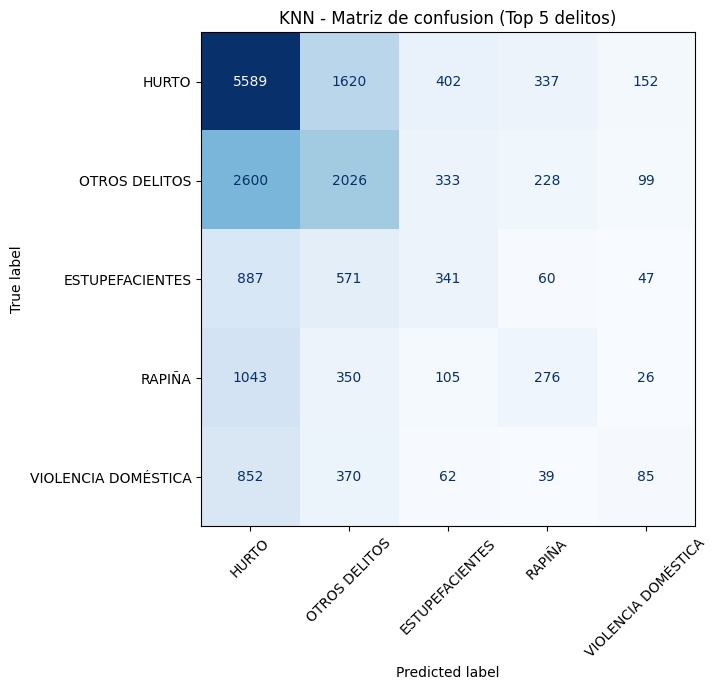

In [92]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# 1) Columnas fijas del problema
col_depto = 'depto_hechos'
col_sexo = 'sexo_persona'
col_situacion = 'situación_procesal'
col_edad = 'edad'
col_fecha = 'fecha_hecho'
col_target = 'delitos_agrupados'

# 2) Armar base para clasificacion (target top 5)
base_cls = df[[col_depto, col_sexo, col_situacion, col_edad, col_fecha, col_target]].copy()
base_cls[col_target] = base_cls[col_target].astype(str).str.strip()
base_cls = base_cls[base_cls[col_target] != ''].copy()

base_cls.head

# Fecha a variables derivadas
base_cls[col_fecha] = pd.to_datetime(base_cls[col_fecha], errors='coerce')
base_cls['anio_hecho'] = base_cls[col_fecha].dt.year
base_cls['mes_hecho'] = base_cls[col_fecha].dt.month
base_cls['dia_semana_hecho'] = base_cls[col_fecha].dt.dayofweek

# Edad numerica (mantiene NaN para imputacion)
base_cls[col_edad] = pd.to_numeric(base_cls[col_edad], errors='coerce')

# Quedarse con top 5 clases mas frecuentes
top5 = base_cls[col_target].value_counts().head(5).index.tolist()
base_cls = base_cls[base_cls[col_target].isin(top5)].copy()

# Eliminar filas sin fecha util para derivadas temporales
base_cls = base_cls.dropna(subset=['anio_hecho', 'mes_hecho', 'dia_semana_hecho']).copy()

X = base_cls[[col_depto, col_sexo, col_situacion, col_edad, 'anio_hecho', 'mes_hecho', 'dia_semana_hecho']]
y = base_cls[col_target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 3) Preprocesamiento para KNN
cat_features = [col_depto, col_sexo, col_situacion]
num_features = ['anio_hecho', 'mes_hecho', 'dia_semana_hecho']

# Evita warning de imputacion cuando edad viene completamente vacia
if X_train[col_edad].notna().any():
    num_features = [col_edad] + num_features
else:
    print("Nota: la columna 'edad' no tiene valores observados en entrenamiento y se excluye del modelo KNN.")

X_train = X_train[cat_features + num_features]
X_test = X_test[cat_features + num_features]

preprocess = ColumnTransformer(
    transformers=[
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('ohe', OneHotEncoder(handle_unknown='ignore'))
        ]), cat_features),
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median'))
        ]), num_features),
    ]
)

knn_clf = Pipeline(steps=[
    ('prep', preprocess),
    ('scale', StandardScaler(with_mean=False)),
    ('model', KNeighborsClassifier(n_neighbors=25, weights='distance', n_jobs=-1))
])

knn_clf.fit(X_train, y_train)
y_pred = knn_clf.predict(X_test)

# 4) Evaluacion del modelo
acc = accuracy_score(y_test, y_pred)
bacc = balanced_accuracy_score(y_test, y_pred)

print('Top 5 delitos modelados:')
for i, c in enumerate(top5, start=1):
    print(f'{i}. {c}')

print(f'\nFilas de entrenamiento: {len(X_train):,}')
print(f'Filas de prueba: {len(X_test):,}')
print(f'Accuracy: {acc:.4f}')
print(f'Balanced accuracy: {bacc:.4f}')

print('\nReporte de clasificacion (test):')
print(classification_report(y_test, y_pred, zero_division=0))

cm = confusion_matrix(y_test, y_pred, labels=top5)
cm_df = pd.DataFrame(
    cm,
    index=[f'Real: {c}' for c in top5],
    columns=[f'Pred: {c}' for c in top5]
)

print('Matriz de confusion (tabla):')
display(cm_df)

# 5) Visualizacion grafica de la matriz de confusion
fig, ax = plt.subplots(figsize=(9, 7))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=top5).plot(
    ax=ax,
    cmap='Blues',
    xticks_rotation=45,
    colorbar=False,
)
plt.title('KNN - Matriz de confusion (Top 5 delitos)')
plt.tight_layout()
plt.show()

## B. Clasificacion con Random Forest: prediccion de `delitos_agrupados` (Top 5)

Se entrena un clasificador Random Forest con las mismas variables del modelo KNN para comparar resultados:
- `depto_hechos`
- `sexo_persona`
- `situación_procesal`
- `edad`
- `fecha_hecho` (descompuesta en anio, mes, dia_semana)

Random Forest - Top 5 delitos modelados:
1. HURTO
2. OTROS DELITOS
3. ESTUPEFACIENTES
4. RAPIÑA
5. VIOLENCIA DOMÉSTICA

Filas de entrenamiento: 73,996
Filas de prueba: 18,500
Accuracy: 0.4183
Balanced accuracy: 0.3071

Reporte de clasificacion (test):
                     precision    recall  f1-score   support

    ESTUPEFACIENTES       0.27      0.21      0.24      1906
              HURTO       0.52      0.58      0.55      8100
      OTROS DELITOS       0.40      0.39      0.39      5286
             RAPIÑA       0.25      0.23      0.24      1800
VIOLENCIA DOMÉSTICA       0.16      0.12      0.14      1408

           accuracy                           0.42     18500
          macro avg       0.32      0.31      0.31     18500
       weighted avg       0.40      0.42      0.41     18500

Matriz de confusion (tabla):


,Pred: HURTO,Pred: OTROS DELITOS,Pred: ESTUPEFACIENTES,Pred: RAPIÑA,Pred: VIOLENCIA DOMÉSTICA
Real: HURTO,4678,1834,469,649,470
Real: OTROS DELITOS,2157,2065,407,394,263
Real: ESTUPEFACIENTES,747,559,403,112,85
Real: RAPIÑA,814,359,113,418,96
Real: VIOLENCIA DOMÉSTICA,653,406,85,90,174


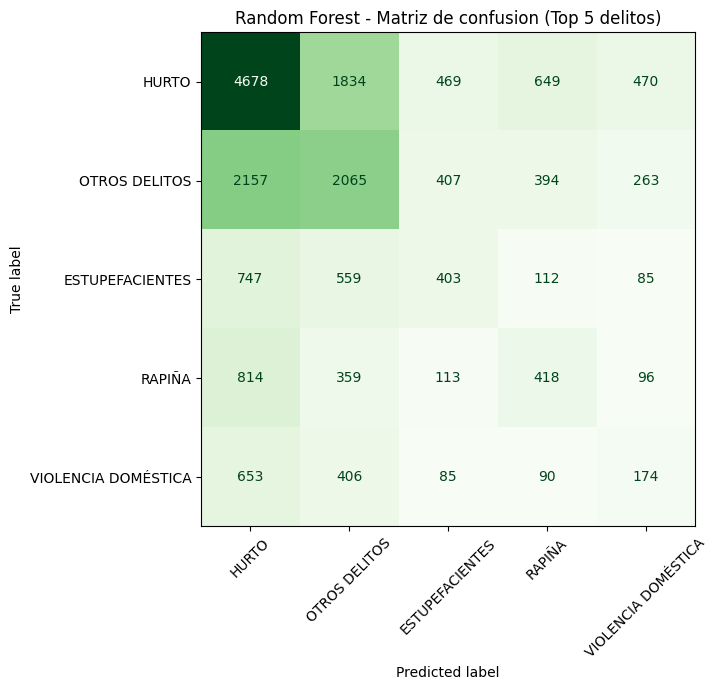

In [97]:
from sklearn.ensemble import RandomForestClassifier

# 1) Base para Random Forest (misma logica que KNN)
base_rf = df[[col_depto, col_sexo, col_situacion, col_edad, col_fecha, col_target]].copy()
base_rf[col_target] = base_rf[col_target].astype(str).str.strip()
base_rf = base_rf[base_rf[col_target] != ''].copy()

base_rf[col_fecha] = pd.to_datetime(base_rf[col_fecha], errors='coerce')
base_rf['anio_hecho'] = base_rf[col_fecha].dt.year
base_rf['mes_hecho'] = base_rf[col_fecha].dt.month
base_rf['dia_semana_hecho'] = base_rf[col_fecha].dt.dayofweek
base_rf[col_edad] = pd.to_numeric(base_rf[col_edad], errors='coerce')

base_rf = base_rf[base_rf[col_target].isin(top5)].copy()
base_rf = base_rf.dropna(subset=['anio_hecho', 'mes_hecho', 'dia_semana_hecho']).copy()

X_rf = base_rf[[col_depto, col_sexo, col_situacion, col_edad, 'anio_hecho', 'mes_hecho', 'dia_semana_hecho']]
y_rf = base_rf[col_target]

stratify_rf = y_rf if y_rf.value_counts().min() >= 2 else None
if stratify_rf is None:
    print("Aviso: se desactiva stratify en RF porque hay clases con menos de 2 casos.")

X_rf_train, X_rf_test, y_rf_train, y_rf_test = train_test_split(
    X_rf, y_rf,
    test_size=0.2,
    random_state=42,
    stratify=stratify_rf
)

# 2) Preprocesamiento (igual que KNN, sin escalado)
rf_cat_features = [col_depto, col_sexo, col_situacion]
rf_num_features = ['anio_hecho', 'mes_hecho', 'dia_semana_hecho']

if X_rf_train[col_edad].notna().any():
    rf_num_features = [col_edad] + rf_num_features
else:
    print("Nota: la columna 'edad' no tiene valores observados en entrenamiento y se excluye del modelo Random Forest.")

X_rf_train = X_rf_train[rf_cat_features + rf_num_features]
X_rf_test = X_rf_test[rf_cat_features + rf_num_features]

rf_preprocess = ColumnTransformer(
    transformers=[
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('ohe', OneHotEncoder(handle_unknown='ignore'))
        ]), rf_cat_features),
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median'))
        ]), rf_num_features),
    ]
)

rf_clf = Pipeline(steps=[
    ('prep', rf_preprocess),
    ('model', RandomForestClassifier(
        n_estimators=400,
        random_state=42,
        class_weight='balanced_subsample',
        n_jobs=-1
    ))
])

rf_clf.fit(X_rf_train, y_rf_train)
y_rf_pred = rf_clf.predict(X_rf_test)

# 3) Evaluacion
rf_acc = accuracy_score(y_rf_test, y_rf_pred)
rf_bacc = balanced_accuracy_score(y_rf_test, y_rf_pred)

print('Random Forest - Top 5 delitos modelados:')
for i, c in enumerate(top5, start=1):
    print(f'{i}. {c}')

print(f'\nFilas de entrenamiento: {len(X_rf_train):,}')
print(f'Filas de prueba: {len(X_rf_test):,}')
print(f'Accuracy: {rf_acc:.4f}')
print(f'Balanced accuracy: {rf_bacc:.4f}')

print('\nReporte de clasificacion (test):')
print(classification_report(y_rf_test, y_rf_pred, zero_division=0))

rf_cm = confusion_matrix(y_rf_test, y_rf_pred, labels=top5)
rf_cm_df = pd.DataFrame(
    rf_cm,
    index=[f'Real: {c}' for c in top5],
    columns=[f'Pred: {c}' for c in top5]
)

print('Matriz de confusion (tabla):')
display(rf_cm_df)

fig, ax = plt.subplots(figsize=(9, 7))
ConfusionMatrixDisplay(confusion_matrix=rf_cm, display_labels=top5).plot(
    ax=ax,
    cmap='Greens',
    xticks_rotation=45,
    colorbar=False,
)
plt.title('Random Forest - Matriz de confusion (Top 5 delitos)')
plt.tight_layout()
plt.show()

## D. Experimento controlado de mejora de performance (KNN y Random Forest)

Se comparan estrategias recomendadas antes de fijar un modelo final:

1. Baseline
2. Balanceo por submuestreo de clases mayoritarias
3. Ajuste de hiperparametros (tuning)
4. `class_weight` + tuning (aplica a Random Forest)

Metricas reportadas:
- Accuracy
- Balanced accuracy
- Macro F1

Objetivo: priorizar desempeño equilibrado entre clases, no solo accuracy global.

Top 5 clases usadas: ['HURTO', 'OTROS DELITOS', 'ESTUPEFACIENTES', 'RAPIÑA', 'VIOLENCIA DOMÉSTICA']

Mejores parametros KNN (tuning):
{'model__weights': 'distance', 'model__p': 2, 'model__n_neighbors': 15, 'model__metric': 'manhattan'}

Mejores parametros RandomForest (tuning):
{'model__n_estimators': 200, 'model__min_samples_leaf': 2, 'model__max_features': 'sqrt', 'model__max_depth': 15, 'model__class_weight': 'balanced'}

Comparacion de estrategias (ordenado por balanced_accuracy dentro de cada modelo):


,modelo,escenario,filas_train,accuracy,balanced_accuracy,macro_f1
0,KNN,2) Balanceo (undersampling),28165,0.307730,0.355876,0.290604
1,KNN,1) Baseline,73996,0.449568,0.293178,0.298817
2,KNN,3) Tuning,29999,0.441568,0.288111,0.293771
3,RandomForest,4) class_weight + tuning,29999,0.357946,0.374393,0.318942
4,RandomForest,3) Balanceo (undersampling),28165,0.305189,0.342555,0.286772
5,RandomForest,2) class_weight,73996,0.418270,0.307085,0.311530
6,RandomForest,1) Baseline,73996,0.436270,0.305225,0.313031


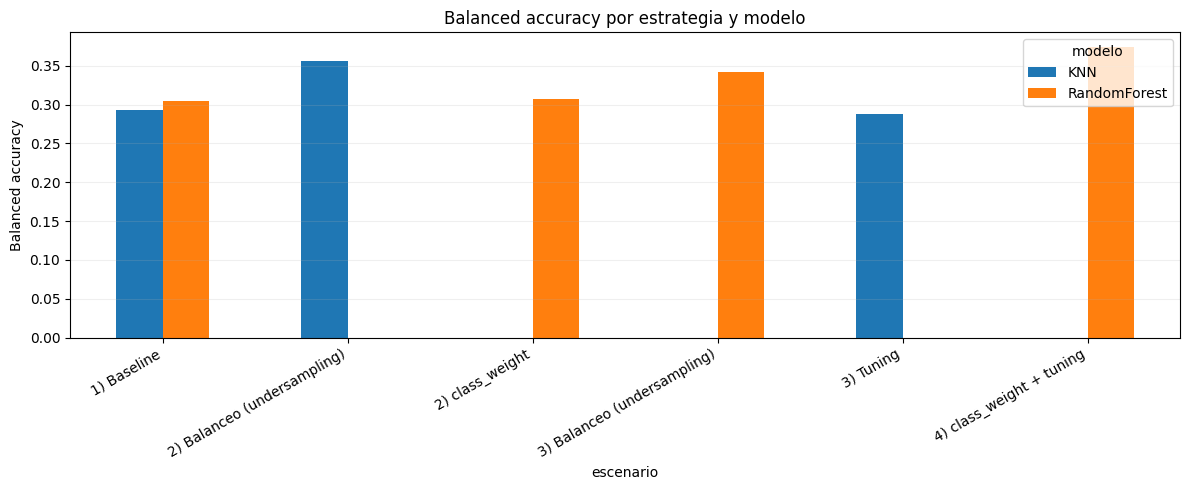

In [4]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score

# ==============================
# 1) Base comun para comparacion
# ==============================
col_depto = 'depto_hechos'
col_sexo = 'sexo_persona'
col_situacion = 'situación_procesal'
col_edad = 'edad'
col_fecha = 'fecha_hecho'
col_target = 'delitos_agrupados'

base_cmp = df[[col_depto, col_sexo, col_situacion, col_edad, col_fecha, col_target]].copy()
base_cmp[col_target] = base_cmp[col_target].astype(str).str.strip()
base_cmp = base_cmp[base_cmp[col_target] != ''].copy()

base_cmp[col_fecha] = pd.to_datetime(base_cmp[col_fecha], errors='coerce')
base_cmp['anio_hecho'] = base_cmp[col_fecha].dt.year
base_cmp['mes_hecho'] = base_cmp[col_fecha].dt.month
base_cmp['dia_semana_hecho'] = base_cmp[col_fecha].dt.dayofweek
base_cmp[col_edad] = pd.to_numeric(base_cmp[col_edad], errors='coerce')

classes_top5 = base_cmp[col_target].value_counts().head(5).index.tolist()
base_cmp = base_cmp[base_cmp[col_target].isin(classes_top5)].copy()
base_cmp = base_cmp.dropna(subset=['anio_hecho', 'mes_hecho', 'dia_semana_hecho']).copy()

X_all = base_cmp[[col_depto, col_sexo, col_situacion, col_edad, 'anio_hecho', 'mes_hecho', 'dia_semana_hecho']]
y_all = base_cmp[col_target]

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42, stratify=y_all
)

# Para evitar warnings/errores internos de KNN con labels string en algunas versiones de sklearn
le_knn = LabelEncoder()
y_train_knn = pd.Series(le_knn.fit_transform(y_train), index=y_train.index)
y_test_knn = pd.Series(le_knn.transform(y_test), index=y_test.index)

cat_features = [col_depto, col_sexo, col_situacion]
num_features = ['anio_hecho', 'mes_hecho', 'dia_semana_hecho']
if X_train[col_edad].notna().any():
    num_features = [col_edad] + num_features

X_train = X_train[cat_features + num_features].copy()
X_test = X_test[cat_features + num_features].copy()

prep_common = ColumnTransformer(
    transformers=[
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('ohe', OneHotEncoder(handle_unknown='ignore'))
        ]), cat_features),
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median'))
        ]), num_features)
    ]
)


def undersample_train(X, y, random_state=42):
    """Submuestrea clases mayoritarias al tamano de la minoritaria."""
    y_series = pd.Series(y, index=X.index, name='_y_')
    min_n = y_series.value_counts().min()

    sampled_idx = []
    for cls in y_series.unique():
        idx_cls = y_series[y_series == cls].index
        sampled_idx.extend(pd.Series(idx_cls).sample(n=min_n, random_state=random_state).tolist())

    sampled_idx = pd.Index(sampled_idx)
    X_s = X.loc[sampled_idx].copy()
    y_s = y_series.loc[sampled_idx].copy()
    return X_s, y_s


def stratified_subsample(X, y, max_n=30000, random_state=42):
    """Submuestra estratificada para acelerar tuning."""
    if len(X) <= max_n:
        return X.copy(), y.copy()

    y_series = pd.Series(y, index=X.index)
    frac = max_n / len(X)
    idx = (
        y_series.groupby(y_series, group_keys=False)
        .apply(lambda s: s.sample(max(1, int(round(len(s) * frac))), random_state=random_state))
        .index
    )
    idx = idx[:max_n]
    return X.loc[idx].copy(), y_series.loc[idx].copy()


def eval_metrics(y_true, y_pred):
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'balanced_accuracy': balanced_accuracy_score(y_true, y_pred),
        'macro_f1': f1_score(y_true, y_pred, average='macro', zero_division=0)
    }


results = []

# ==============================
# 2) KNN - Baseline
# ==============================
knn_base = Pipeline(steps=[
    ('prep', prep_common),
    ('scale', StandardScaler(with_mean=False)),
    ('model', KNeighborsClassifier(n_neighbors=25, weights='distance', n_jobs=-1))
])
knn_base.fit(X_train, y_train_knn)
y_pred_knn_base = knn_base.predict(X_test)
results.append({'modelo': 'KNN', 'escenario': '1) Baseline', 'filas_train': len(X_train), **eval_metrics(y_test_knn, y_pred_knn_base)})

# ==============================
# 3) KNN - Balanceo
# ==============================
X_train_bal_knn, y_train_bal_knn = undersample_train(X_train, y_train_knn, random_state=42)
knn_bal = Pipeline(steps=[
    ('prep', prep_common),
    ('scale', StandardScaler(with_mean=False)),
    ('model', KNeighborsClassifier(n_neighbors=25, weights='distance', n_jobs=-1))
])
knn_bal.fit(X_train_bal_knn, y_train_bal_knn)
y_pred_knn_bal = knn_bal.predict(X_test)
results.append({'modelo': 'KNN', 'escenario': '2) Balanceo (undersampling)', 'filas_train': len(X_train_bal_knn), **eval_metrics(y_test_knn, y_pred_knn_bal)})

# ==============================
# 4) KNN - Tuning
# ==============================
X_tune_knn, y_tune_knn = stratified_subsample(X_train, y_train_knn, max_n=30000, random_state=42)

knn_tune = Pipeline(steps=[
    ('prep', prep_common),
    ('scale', StandardScaler(with_mean=False)),
    ('model', KNeighborsClassifier(n_jobs=-1))
])

knn_param_dist = {
    'model__n_neighbors': [9, 15, 25, 35, 45],
    'model__weights': ['uniform', 'distance'],
    'model__metric': ['minkowski', 'manhattan'],
    'model__p': [1, 2]
}

knn_search = RandomizedSearchCV(
    estimator=knn_tune,
    param_distributions=knn_param_dist,
    n_iter=12,
    scoring='balanced_accuracy',
    cv=3,
    random_state=42,
    n_jobs=1,
    verbose=0
)
knn_search.fit(X_tune_knn, y_tune_knn)

best_knn = knn_search.best_estimator_
y_pred_knn_tuned = best_knn.predict(X_test)
results.append({'modelo': 'KNN', 'escenario': '3) Tuning', 'filas_train': len(X_tune_knn), **eval_metrics(y_test_knn, y_pred_knn_tuned)})

# ==============================
# 5) RF - Baseline
# ==============================
rf_base = Pipeline(steps=[
    ('prep', prep_common),
    ('model', RandomForestClassifier(n_estimators=400, random_state=42, n_jobs=-1))
])
rf_base.fit(X_train, y_train)
y_pred_rf_base = rf_base.predict(X_test)
results.append({'modelo': 'RandomForest', 'escenario': '1) Baseline', 'filas_train': len(X_train), **eval_metrics(y_test, y_pred_rf_base)})

# ==============================
# 6) RF - class_weight
# ==============================
rf_w = Pipeline(steps=[
    ('prep', prep_common),
    ('model', RandomForestClassifier(
        n_estimators=400,
        random_state=42,
        class_weight='balanced_subsample',
        n_jobs=-1
    ))
])
rf_w.fit(X_train, y_train)
y_pred_rf_w = rf_w.predict(X_test)
results.append({'modelo': 'RandomForest', 'escenario': '2) class_weight', 'filas_train': len(X_train), **eval_metrics(y_test, y_pred_rf_w)})

# ==============================
# 7) RF - Balanceo
# ==============================
X_train_bal_rf, y_train_bal_rf = undersample_train(X_train, y_train, random_state=42)
rf_bal = Pipeline(steps=[
    ('prep', prep_common),
    ('model', RandomForestClassifier(n_estimators=400, random_state=42, n_jobs=-1))
])
rf_bal.fit(X_train_bal_rf, y_train_bal_rf)
y_pred_rf_bal = rf_bal.predict(X_test)
results.append({'modelo': 'RandomForest', 'escenario': '3) Balanceo (undersampling)', 'filas_train': len(X_train_bal_rf), **eval_metrics(y_test, y_pred_rf_bal)})

# ==============================
# 8) RF - class_weight + tuning
# ==============================
X_tune_rf, y_tune_rf = stratified_subsample(X_train, y_train, max_n=30000, random_state=42)

rf_tune = Pipeline(steps=[
    ('prep', prep_common),
    ('model', RandomForestClassifier(random_state=42, n_jobs=-1))
])

rf_param_dist = {
    'model__n_estimators': [200, 300, 400],
    'model__max_depth': [None, 15, 25, 35],
    'model__min_samples_leaf': [1, 2, 5],
    'model__max_features': ['sqrt', 'log2', 0.5],
    'model__class_weight': ['balanced', 'balanced_subsample']
}

rf_search = RandomizedSearchCV(
    estimator=rf_tune,
    param_distributions=rf_param_dist,
    n_iter=12,
    scoring='balanced_accuracy',
    cv=3,
    random_state=42,
    n_jobs=1,
    verbose=0
)
rf_search.fit(X_tune_rf, y_tune_rf)

best_rf = rf_search.best_estimator_
y_pred_rf_tuned = best_rf.predict(X_test)
results.append({'modelo': 'RandomForest', 'escenario': '4) class_weight + tuning', 'filas_train': len(X_tune_rf), **eval_metrics(y_test, y_pred_rf_tuned)})

# ==============================
# 9) Resumen comparativo
# ==============================
res_df = pd.DataFrame(results)
res_df = res_df.sort_values(['modelo', 'balanced_accuracy', 'macro_f1'], ascending=[True, False, False]).reset_index(drop=True)

print('Top 5 clases usadas:', classes_top5)
print('\nMejores parametros KNN (tuning):')
print(knn_search.best_params_)
print('\nMejores parametros RandomForest (tuning):')
print(rf_search.best_params_)

print('\nComparacion de estrategias (ordenado por balanced_accuracy dentro de cada modelo):')
display(res_df)

plot_df = res_df.pivot(index='escenario', columns='modelo', values='balanced_accuracy').fillna(0)
ax = plot_df.plot(kind='bar', figsize=(12, 5))
ax.set_title('Balanced accuracy por estrategia y modelo')
ax.set_ylabel('Balanced accuracy')
ax.grid(axis='y', alpha=0.2)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## E. Matriz de confusion de los mejores modelos por balanced accuracy

Se selecciona automaticamente, para cada familia (KNN y Random Forest), el escenario con mayor `balanced_accuracy` del experimento E, y se grafica su matriz de confusion en test.

Mejor escenario KNN:
escenario            2) Balanceo (undersampling)
balanced_accuracy                       0.355876
macro_f1                                0.290604
accuracy                                 0.30773
Name: 0, dtype: object

Mejor escenario Random Forest:
escenario            4) class_weight + tuning
balanced_accuracy                    0.374393
macro_f1                             0.318942
accuracy                             0.357946
Name: 3, dtype: object


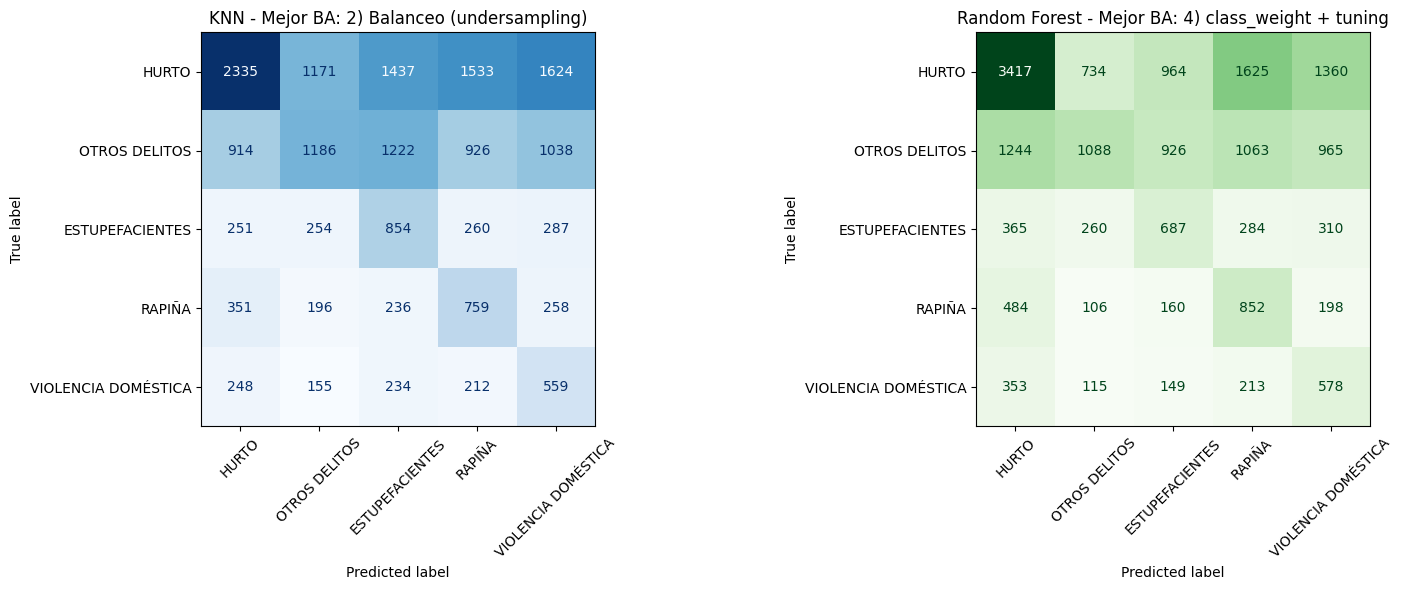


Matriz de confusion KNN (mejor balanced accuracy):


,Pred: HURTO,Pred: OTROS DELITOS,Pred: ESTUPEFACIENTES,Pred: RAPIÑA,Pred: VIOLENCIA DOMÉSTICA
Real: HURTO,2335,1171,1437,1533,1624
Real: OTROS DELITOS,914,1186,1222,926,1038
Real: ESTUPEFACIENTES,251,254,854,260,287
Real: RAPIÑA,351,196,236,759,258
Real: VIOLENCIA DOMÉSTICA,248,155,234,212,559



Matriz de confusion Random Forest (mejor balanced accuracy):


,Pred: HURTO,Pred: OTROS DELITOS,Pred: ESTUPEFACIENTES,Pred: RAPIÑA,Pred: VIOLENCIA DOMÉSTICA
Real: HURTO,3417,734,964,1625,1360
Real: OTROS DELITOS,1244,1088,926,1063,965
Real: ESTUPEFACIENTES,365,260,687,284,310
Real: RAPIÑA,484,106,160,852,198
Real: VIOLENCIA DOMÉSTICA,353,115,149,213,578


In [6]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1) Elegir el mejor escenario por balanced accuracy para cada modelo
best_knn_row = (
    res_df[res_df['modelo'] == 'KNN']
    .sort_values(['balanced_accuracy', 'macro_f1'], ascending=False)
    .iloc[0]
)
best_rf_row = (
    res_df[res_df['modelo'] == 'RandomForest']
    .sort_values(['balanced_accuracy', 'macro_f1'], ascending=False)
    .iloc[0]
)

best_knn_escenario = best_knn_row['escenario']
best_rf_escenario = best_rf_row['escenario']

# 2) Predicciones disponibles por escenario (ya calculadas en la celda E)
knn_preds = {
    '1) Baseline': y_pred_knn_base,
    '2) Balanceo (undersampling)': y_pred_knn_bal,
    '3) Tuning': y_pred_knn_tuned,
}
rf_preds = {
    '1) Baseline': y_pred_rf_base,
    '2) class_weight': y_pred_rf_w,
    '3) Balanceo (undersampling)': y_pred_rf_bal,
    '4) class_weight + tuning': y_pred_rf_tuned,
}

# 3) Recuperar y_true / y_pred para el mejor KNN y convertir a etiquetas originales
y_pred_knn_best = knn_preds[best_knn_escenario]
y_true_knn_labels = le_knn.inverse_transform(y_test_knn.astype(int))
y_pred_knn_labels = le_knn.inverse_transform(pd.Series(y_pred_knn_best).astype(int))

cm_knn_best = confusion_matrix(y_true_knn_labels, y_pred_knn_labels, labels=classes_top5)

# 4) Recuperar y_true / y_pred para el mejor Random Forest
y_pred_rf_best = rf_preds[best_rf_escenario]
cm_rf_best = confusion_matrix(y_test, y_pred_rf_best, labels=classes_top5)

print('Mejor escenario KNN:')
print(best_knn_row[['escenario', 'balanced_accuracy', 'macro_f1', 'accuracy']])
print('\nMejor escenario Random Forest:')
print(best_rf_row[['escenario', 'balanced_accuracy', 'macro_f1', 'accuracy']])

# 5) Graficar ambas matrices de confusion
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ConfusionMatrixDisplay(confusion_matrix=cm_knn_best, display_labels=classes_top5).plot(
    ax=axes[0],
    cmap='Blues',
    xticks_rotation=45,
    colorbar=False,
)
axes[0].set_title(f'KNN - Mejor BA: {best_knn_escenario}')

ConfusionMatrixDisplay(confusion_matrix=cm_rf_best, display_labels=classes_top5).plot(
    ax=axes[1],
    cmap='Greens',
    xticks_rotation=45,
    colorbar=False,
)
axes[1].set_title(f'Random Forest - Mejor BA: {best_rf_escenario}')

plt.tight_layout()
plt.show()

# 6) Tablas de apoyo
cm_knn_df = pd.DataFrame(
    cm_knn_best,
    index=[f'Real: {c}' for c in classes_top5],
    columns=[f'Pred: {c}' for c in classes_top5],
)
cm_rf_df = pd.DataFrame(
    cm_rf_best,
    index=[f'Real: {c}' for c in classes_top5],
    columns=[f'Pred: {c}' for c in classes_top5],
)

print('\nMatriz de confusion KNN (mejor balanced accuracy):')
display(cm_knn_df)
print('\nMatriz de confusion Random Forest (mejor balanced accuracy):')
display(cm_rf_df)

## F. Nuevas features de reincidencia + remodeado KNN y Random Forest

Se agregan dos columnas al dataset original:

- `es_reincidente`: 1 si ese registro tiene un antecedente previo del mismo individuo (segun fecha), 0 si no.
- `ultimo_delito_individuo`: ultimo `delitos_agrupados` previo del mismo individuo (ordenado por fecha). Si no tiene historial previo, se marca como `Sin historial previo`.

Luego se reentrenan los modelos con estas dos variables adicionales usando:

- KNN con balanceo por undersampling en entrenamiento.
- Random Forest con `class_weight` + tuning por `balanced_accuracy`.

Columnas agregadas al dataset: es_reincidente, ultimo_delito_individuo
   es_reincidente ultimo_delito_individuo
0               0    Sin historial previo
1               0    Sin historial previo
2               0    Sin historial previo
3               0    Sin historial previo
4               0    Sin historial previo
5               0    Sin historial previo
6               0    Sin historial previo
7               0    Sin historial previo
8               0    Sin historial previo
9               0    Sin historial previo
Filas inconsistentes (deberia ser 0): 0
Top 5 clases usadas (nuevo modelado): ['HURTO', 'OTROS DELITOS', 'ESTUPEFACIENTES', 'RAPIÑA', 'VIOLENCIA DOMÉSTICA']

KNN con undersampling:
Filas train balanceadas KNN: 28,165
Accuracy: 0.3624
Balanced accuracy: 0.4002
Macro F1: 0.3315

Random Forest con class_weight + tuning:
Filas train usadas en tuning RF: 15,000
Mejores parametros RF:
{'model__n_estimators': 300, 'model__min_samples_leaf': 4, 'model__max_features': 'sq

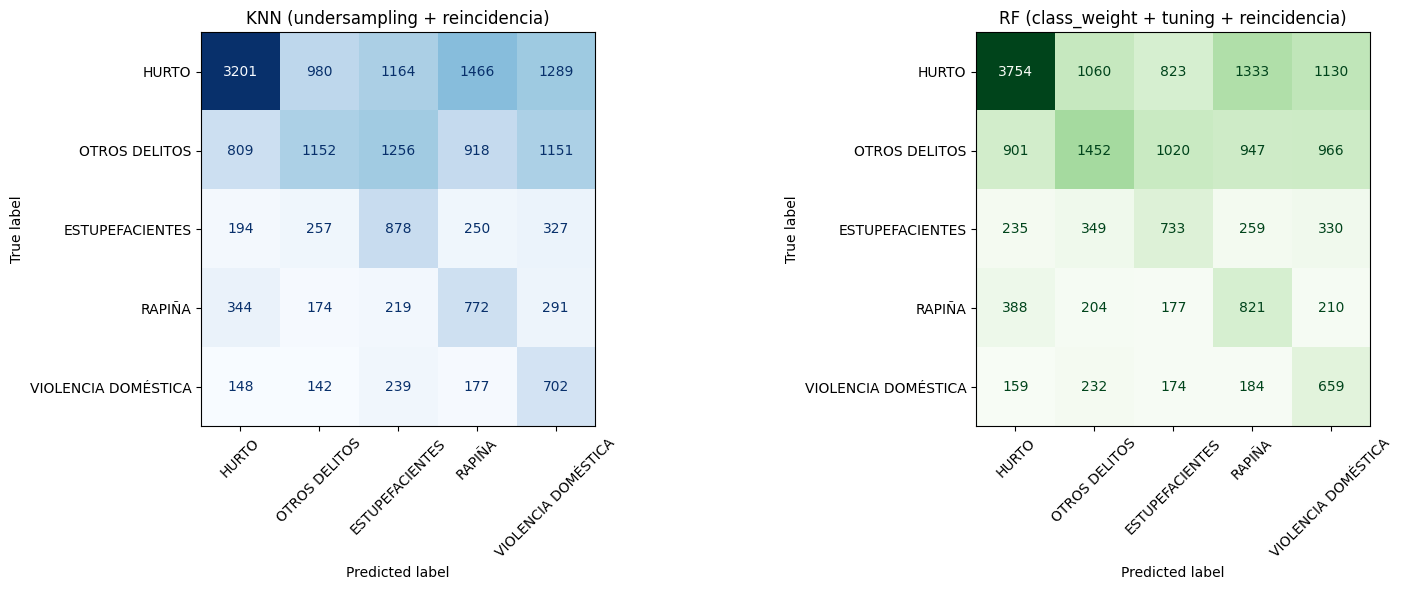


Matriz de confusion KNN (undersampling + nuevas features):


,Pred: HURTO,Pred: OTROS DELITOS,Pred: ESTUPEFACIENTES,Pred: RAPIÑA,Pred: VIOLENCIA DOMÉSTICA
Real: HURTO,3201,980,1164,1466,1289
Real: OTROS DELITOS,809,1152,1256,918,1151
Real: ESTUPEFACIENTES,194,257,878,250,327
Real: RAPIÑA,344,174,219,772,291
Real: VIOLENCIA DOMÉSTICA,148,142,239,177,702



Matriz de confusion Random Forest (class_weight + tuning + nuevas features):


,Pred: HURTO,Pred: OTROS DELITOS,Pred: ESTUPEFACIENTES,Pred: RAPIÑA,Pred: VIOLENCIA DOMÉSTICA
Real: HURTO,3754,1060,823,1333,1130
Real: OTROS DELITOS,901,1452,1020,947,966
Real: ESTUPEFACIENTES,235,349,733,259,330
Real: RAPIÑA,388,204,177,821,210
Real: VIOLENCIA DOMÉSTICA,159,232,174,184,659


In [10]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import balanced_accuracy_score, accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

# ==============================
# 1) Construir columnas de reincidencia en df
# ==============================
if 'id_documento' not in df.columns:
    raise KeyError("La columna 'id_documento' no existe en el dataset.")

if 'fecha_hecho' not in df.columns:
    raise KeyError("La columna 'fecha_hecho' no existe en el dataset.")

if 'delitos_agrupados' not in df.columns:
    raise KeyError("La columna 'delitos_agrupados' no existe en el dataset.")

base_rec = df[['id_documento', 'fecha_hecho', 'delitos_agrupados']].copy()
base_rec['id_documento'] = base_rec['id_documento'].astype(str).str.strip()
base_rec['id_documento'] = base_rec['id_documento'].replace({'': pd.NA, 'nan': pd.NA, 'None': pd.NA})
base_rec['fecha_hecho'] = pd.to_datetime(base_rec['fecha_hecho'], errors='coerce')
base_rec['delitos_agrupados'] = base_rec['delitos_agrupados'].astype(str).str.strip()
base_rec['delitos_agrupados'] = base_rec['delitos_agrupados'].replace({'': pd.NA, 'nan': pd.NA, 'None': pd.NA})

# Orden cronologico para obtener el ultimo delito previo por individuo
base_rec_sorted = base_rec.reset_index().sort_values(['id_documento', 'fecha_hecho', 'index'], kind='mergesort')
base_rec_sorted['ultimo_delito_individuo'] = base_rec_sorted.groupby('id_documento')['delitos_agrupados'].shift(1)

# Reincidente a nivel registro: solo si existe delito previo real para ese individuo
base_rec_sorted['es_reincidente'] = base_rec_sorted['ultimo_delito_individuo'].notna().astype(int)

base_rec_back = base_rec_sorted.set_index('index').sort_index()

df['es_reincidente'] = base_rec_back['es_reincidente'].fillna(0).astype(int)
df['ultimo_delito_individuo'] = base_rec_back['ultimo_delito_individuo']
df['ultimo_delito_individuo'] = df['ultimo_delito_individuo'].fillna('Sin historial previo')

inconsistencias = ((df['es_reincidente'] == 1) & (df['ultimo_delito_individuo'] == 'Sin historial previo')).sum()

print('Columnas agregadas al dataset: es_reincidente, ultimo_delito_individuo')
print(df[['es_reincidente', 'ultimo_delito_individuo']].head(10))
print(f'Filas inconsistentes (deberia ser 0): {inconsistencias}')


def undersample_train(X, y, random_state=42):
    """Submuestrea clases mayoritarias al tamano de la minoritaria."""
    y_series = pd.Series(y, index=X.index, name='_y_')
    min_n = y_series.value_counts().min()

    sampled_idx = []
    for cls in y_series.unique():
        idx_cls = y_series[y_series == cls].index
        sampled_idx.extend(pd.Series(idx_cls).sample(n=min_n, random_state=random_state).tolist())

    sampled_idx = pd.Index(sampled_idx)
    X_s = X.loc[sampled_idx].copy()
    y_s = y_series.loc[sampled_idx].copy()
    return X_s, y_s


def stratified_subsample(X, y, max_n=15000, random_state=42):
    """Submuestra estratificada para acelerar tuning."""
    if len(X) <= max_n:
        return X.copy(), y.copy()

    y_series = pd.Series(y, index=X.index)
    frac = max_n / len(X)
    idx = (
        y_series.groupby(y_series, group_keys=False)
        .apply(lambda s: s.sample(max(1, int(round(len(s) * frac))), random_state=random_state))
        .index
    )
    idx = idx[:max_n]
    return X.loc[idx].copy(), y_series.loc[idx].copy()


# ==============================
# 2) Remodeado con nuevas features (Top 5 delitos)
# ==============================
col_depto = 'depto_hechos'
col_sexo = 'sexo_persona'
col_situacion = 'situación_procesal'
col_edad = 'edad'
col_fecha = 'fecha_hecho'
col_target = 'delitos_agrupados'
col_rec = 'es_reincidente'
col_ult_del = 'ultimo_delito_individuo'

base_new = df[[col_depto, col_sexo, col_situacion, col_edad, col_fecha, col_rec, col_ult_del, col_target]].copy()
base_new[col_target] = base_new[col_target].astype(str).str.strip()
base_new = base_new[base_new[col_target] != ''].copy()

base_new[col_fecha] = pd.to_datetime(base_new[col_fecha], errors='coerce')
base_new['anio_hecho'] = base_new[col_fecha].dt.year
base_new['mes_hecho'] = base_new[col_fecha].dt.month
base_new['dia_semana_hecho'] = base_new[col_fecha].dt.dayofweek
base_new[col_edad] = pd.to_numeric(base_new[col_edad], errors='coerce')
base_new[col_rec] = pd.to_numeric(base_new[col_rec], errors='coerce').fillna(0).astype(int)
base_new[col_ult_del] = base_new[col_ult_del].astype(str).str.strip().replace({'': 'Sin historial previo', 'nan': 'Sin historial previo'})

classes_top5_new = base_new[col_target].value_counts().head(5).index.tolist()
base_new = base_new[base_new[col_target].isin(classes_top5_new)].copy()
base_new = base_new.dropna(subset=['anio_hecho', 'mes_hecho', 'dia_semana_hecho']).copy()

X_new = base_new[[
    col_depto, col_sexo, col_situacion, col_edad,
    'anio_hecho', 'mes_hecho', 'dia_semana_hecho',
    col_rec, col_ult_del
]]
y_new = base_new[col_target]

X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(
    X_new, y_new, test_size=0.2, random_state=42, stratify=y_new
)

le_knn_new = LabelEncoder()
y_train_knn_new = pd.Series(le_knn_new.fit_transform(y_train_new), index=y_train_new.index)
y_test_knn_new = pd.Series(le_knn_new.transform(y_test_new), index=y_test_new.index)

cat_features_new = [col_depto, col_sexo, col_situacion, col_ult_del]
num_features_new = ['anio_hecho', 'mes_hecho', 'dia_semana_hecho', col_rec]
if X_train_new[col_edad].notna().any():
    num_features_new = [col_edad] + num_features_new

X_train_new = X_train_new[cat_features_new + num_features_new].copy()
X_test_new = X_test_new[cat_features_new + num_features_new].copy()

prep_new = ColumnTransformer(
    transformers=[
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('ohe', OneHotEncoder(handle_unknown='ignore'))
        ]), cat_features_new),
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median'))
        ]), num_features_new)
    ]
)

# ==============================
# 3) KNN con balanceo (undersampling)
# ==============================
X_train_knn_bal_new, y_train_knn_bal_new = undersample_train(X_train_new, y_train_knn_new, random_state=42)

knn_new = Pipeline(steps=[
    ('prep', prep_new),
    ('scale', StandardScaler(with_mean=False)),
    ('model', KNeighborsClassifier(n_neighbors=25, weights='distance', n_jobs=-1))
])
knn_new.fit(X_train_knn_bal_new, y_train_knn_bal_new)
y_pred_knn_new = knn_new.predict(X_test_new)

y_true_knn_new_labels = le_knn_new.inverse_transform(y_test_knn_new.astype(int))
y_pred_knn_new_labels = le_knn_new.inverse_transform(pd.Series(y_pred_knn_new).astype(int))

knn_new_acc = accuracy_score(y_true_knn_new_labels, y_pred_knn_new_labels)
knn_new_bacc = balanced_accuracy_score(y_true_knn_new_labels, y_pred_knn_new_labels)
knn_new_f1 = f1_score(y_true_knn_new_labels, y_pred_knn_new_labels, average='macro', zero_division=0)
cm_knn_new = confusion_matrix(y_true_knn_new_labels, y_pred_knn_new_labels, labels=classes_top5_new)

# ==============================
# 4) Random Forest con class_weight + tuning
# ==============================
X_tune_rf_new, y_tune_rf_new = stratified_subsample(X_train_new, y_train_new, max_n=15000, random_state=42)

rf_tune_new = Pipeline(steps=[
    ('prep', prep_new),
    ('model', RandomForestClassifier(random_state=42, n_jobs=-1))
])

rf_param_dist_new = {
    'model__n_estimators': [150, 200, 300],
    'model__max_depth': [None, 12, 20],
    'model__min_samples_leaf': [1, 2, 4],
    'model__max_features': ['sqrt', 'log2'],
    'model__class_weight': ['balanced', 'balanced_subsample']
}

rf_search_new = RandomizedSearchCV(
    estimator=rf_tune_new,
    param_distributions=rf_param_dist_new,
    n_iter=8,
    scoring='balanced_accuracy',
    cv=2,
    random_state=42,
    n_jobs=1,
    verbose=0
)
rf_search_new.fit(X_tune_rf_new, y_tune_rf_new)

rf_new = rf_search_new.best_estimator_
y_pred_rf_new = rf_new.predict(X_test_new)

rf_new_acc = accuracy_score(y_test_new, y_pred_rf_new)
rf_new_bacc = balanced_accuracy_score(y_test_new, y_pred_rf_new)
rf_new_f1 = f1_score(y_test_new, y_pred_rf_new, average='macro', zero_division=0)
cm_rf_new = confusion_matrix(y_test_new, y_pred_rf_new, labels=classes_top5_new)

print('Top 5 clases usadas (nuevo modelado):', classes_top5_new)
print('\nKNN con undersampling:')
print(f'Filas train balanceadas KNN: {len(X_train_knn_bal_new):,}')
print(f'Accuracy: {knn_new_acc:.4f}')
print(f'Balanced accuracy: {knn_new_bacc:.4f}')
print(f'Macro F1: {knn_new_f1:.4f}')

print('\nRandom Forest con class_weight + tuning:')
print(f'Filas train usadas en tuning RF: {len(X_tune_rf_new):,}')
print('Mejores parametros RF:')
print(rf_search_new.best_params_)
print(f'Accuracy: {rf_new_acc:.4f}')
print(f'Balanced accuracy: {rf_new_bacc:.4f}')
print(f'Macro F1: {rf_new_f1:.4f}')

# ==============================
# 5) Matrices de confusion
# ==============================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ConfusionMatrixDisplay(confusion_matrix=cm_knn_new, display_labels=classes_top5_new).plot(
    ax=axes[0],
    cmap='Blues',
    xticks_rotation=45,
    colorbar=False,
)
axes[0].set_title('KNN (undersampling + reincidencia)')

ConfusionMatrixDisplay(confusion_matrix=cm_rf_new, display_labels=classes_top5_new).plot(
    ax=axes[1],
    cmap='Greens',
    xticks_rotation=45,
    colorbar=False,
)
axes[1].set_title('RF (class_weight + tuning + reincidencia)')

plt.tight_layout()
plt.show()

cm_knn_new_df = pd.DataFrame(
    cm_knn_new,
    index=[f'Real: {c}' for c in classes_top5_new],
    columns=[f'Pred: {c}' for c in classes_top5_new],
)
cm_rf_new_df = pd.DataFrame(
    cm_rf_new,
    index=[f'Real: {c}' for c in classes_top5_new],
    columns=[f'Pred: {c}' for c in classes_top5_new],
)

print('\nMatriz de confusion KNN (undersampling + nuevas features):')
display(cm_knn_new_df)
print('\nMatriz de confusion Random Forest (class_weight + tuning + nuevas features):')
display(cm_rf_new_df)